# Geometría Geoespacial

In [1]:
# Librerias base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# Librerias que permiten trabajar con datos geoespaciales
import geopandas as gpd
from libpysal import weights
import esda
import spreg
from splot import esda as esdaplot
from splot.esda import plot_moran

# Librerias para modelo 
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestClassifier


# Para el análisis descriptivo inicial de contraste de asociación  
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

# Librería para hacer la tramificación, agrupación y transformación WOE
from optbinning import Scorecard, BinningProcess, OptimalBinning
from optbinning.scorecard import plot_auc_roc, plot_cap, plot_ks, ScorecardMonitoring

from Funciones import * # Script donde se han incluido variedad de funciones personalizadas

In [ ]:
# Carga de los datos 
df_train_raw = gpd.read_file('../Input/ModelingDatasets/Train/df_train_with_score_ZCTACoordinates.shp')
# Se cambian los nombres que se perdieron al guardar el archivo en formato .shp
df_train = cleanDataframe2(df_train_raw)
df_train.head(3)

In [3]:
# Informacion general de los datos de entrenamiento
df_train.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 171737 entries, 0 to 171736
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   dc_dist                 171737 non-null  int64         
 1   psa                     171685 non-null  object        
 2   date                    171737 non-null  datetime64[ms]
 3   hour                    171737 non-null  int32         
 4   crime_description       171737 non-null  object        
 5   time_of_day             171737 non-null  object        
 6   day_of_week             171737 non-null  object        
 7   week_of_year            171737 non-null  int64         
 8   month                   171737 non-null  object        
 9   season                  171737 non-null  object        
 10  is_holiday              171737 non-null  bool          
 11  crimeType               171737 non-null  object        
 12  ZCTA                  

## Análisis de los datos

Ahora graficamos algunas variables que componen mi base de entrenamiento para intentar identificar si podría existir correlación espacial. En este caso, nuestra variable target muestra un nivel de correlación bastante visible.

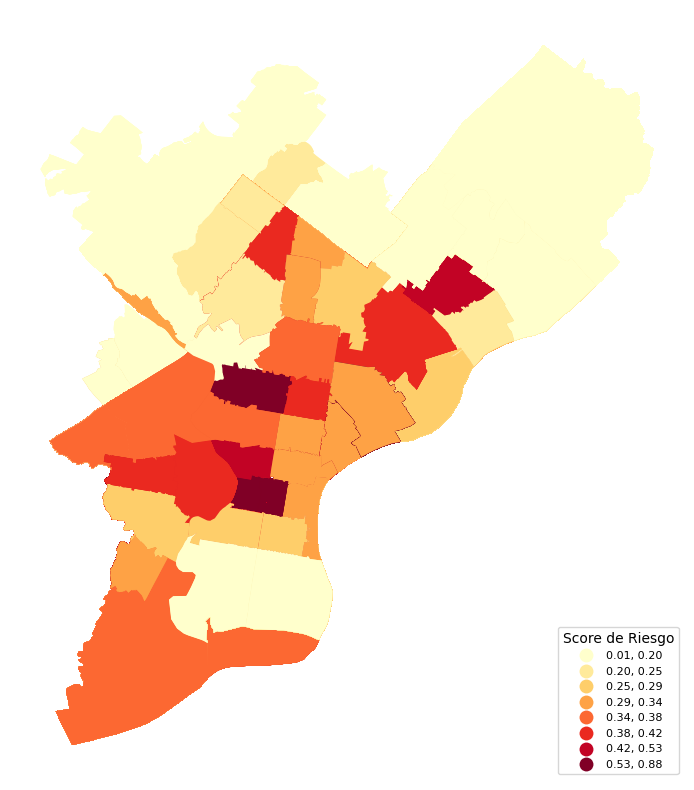

In [4]:
map=df_train.plot(column='risk_score', 
         scheme='quantiles',
         k=8, cmap='YlOrRd',
         legend=True,
         figsize=(10,10),
         legend_kwds={'loc': 'lower right', 'fontsize':'8', 'title':'Score de Riesgo'} 
)
map.set_axis_off()    

Ahora se hace lo mismo pero para el Índice de Gini, que se encarga de cuantificar la desigualdad en los ingresos de la población, y entre más cercano a 1, mayor desigualdad. Acá notamos un patrón interesante y es que en las zonas en en donde el índice es mál alto, coinciden en su mayoría con zonas en donde se tienen niveles de score de riesgo alto. La zona central de Filadelfia es una clara evidencia de ello y entre más nos alejamos el índice tiende a disminuir, algo totalmente análogo a lo que sucede con el score.

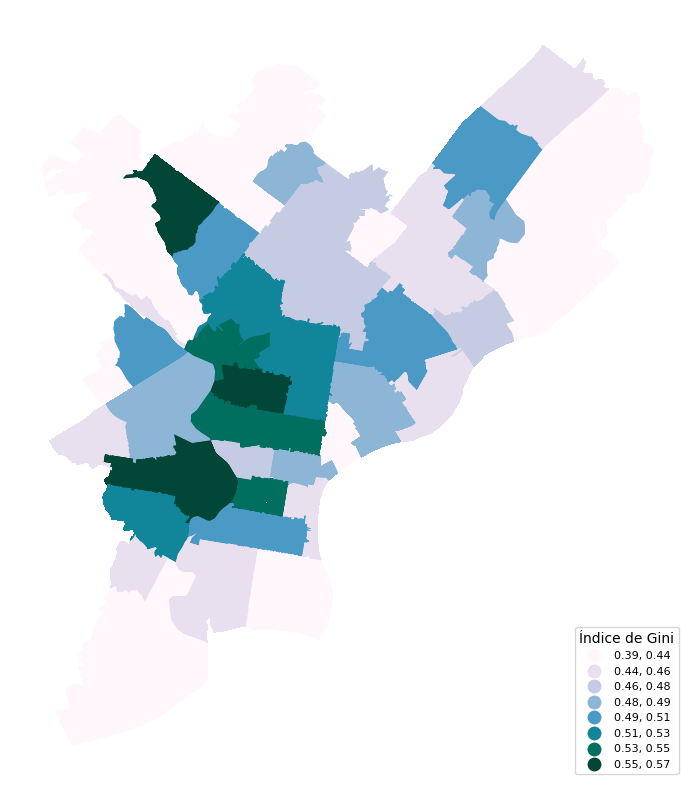

In [5]:
map=df_train.plot(column='GiniIndex', 
         scheme='quantiles',
         k=8, cmap='PuBuGn',
         legend=True,
         figsize=(10,10),
         legend_kwds={'loc': 'lower right', 'fontsize':'8', 'title':'Índice de Gini'} 
)
map.set_axis_off() 

Con el ingreso medio más bien sucede lo contrario. Las zonas que reportan los ingresos anuales más altos tienden a estar lejos del centro de la ciudad por lo que podemos intuir una asociación negativa entre el ingreso medio y lo segura que puede llegar a ser la zona. Todos estas relaciones se estudiarán a mayor profundidad con el Índice de Correlación de Moran más adelante. 

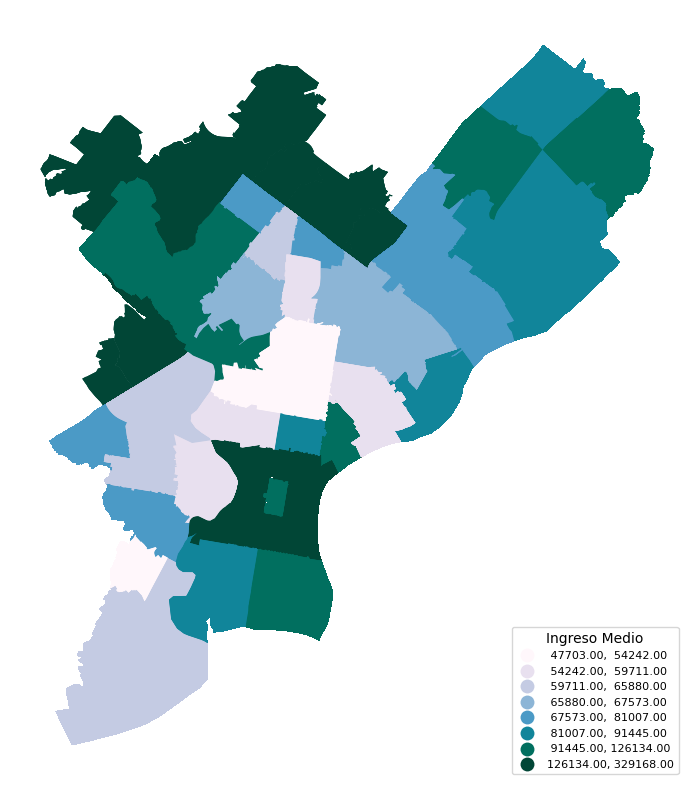

In [6]:
map=df_train.plot(column='mean_income', 
         scheme='quantiles',
         k=8, cmap='PuBuGn',
         legend=True,
         figsize=(10,10),
         legend_kwds={'loc': 'lower right', 'fontsize':'8', 'title':'Ingreso Medio'} 
)
map.set_axis_off() 

## Se construye matriz de Contiguidad

Se procede a agrupar los datos por ZCTA para calcular un promedio del score de riesgo. Esto se hace así dado que para calcular la matriz de contigüididad solo es neceario los polígonos (coordenadas) de cada código ZCTA.  Para el resto de las variables basta tomar el primer valor (first) dado que fueron calculos que ya estaban agrupados por código ZCTA.

In [4]:
df_train.columns

Index(['dc_dist', 'psa', 'date', 'hour', 'crime_description', 'time_of_day',
       'day_of_week', 'week_of_year', 'month', 'season', 'is_holiday',
       'crimeType', 'ZCTA', 'area_mile2', 'population', 'white_race',
       'black_race', 'asian_race', 'latino_race', 'density_mile2',
       'median_income', 'mean_income', 'total_households',
       'household_25k_or_less', 'household_25k_to_50k',
       'household_50k_to_150k', 'household_150k_or_more', 'GiniIndex',
       'risk_score', 'risk_level', 'geometry'],
      dtype='object')

In [5]:
# Se hace agrupamiento
aggregate_df_train = df_train.groupby(['ZCTA']).agg({
    'geometry': 'first',
    'area_mile2' : 'first',
    'density_mile2': 'first',
    'population': 'first',
    'white_race':'first',
    'black_race':'first',
    'latino_race':'first',
    'asian_race':'first',
    'mean_income': 'first',
    'median_income' :'first',
    'total_households': 'first',
    'household_25k_or_less': 'first',
    'household_25k_to_50k': 'first',
    'household_50k_to_150k':'first',
    'household_150k_or_more': 'first',
    'GiniIndex': 'first',
    'risk_score': 'mean',
}).reset_index()

# Asegurar que sigue siendo GeoDataFrame
aggregate_df_train = gpd.GeoDataFrame(aggregate_df_train, geometry='geometry')
# Resumen 
aggregate_df_train.head(3)

,ZCTA,geometry,area_mile2,density_mile2,population,white_race,black_race,latino_race,asian_race,mean_income,median_income,total_households,household_25k_or_less,household_25k_to_50k,household_50k_to_150k,household_150k_or_more,GiniIndex,risk_score
0,19004,"POLYGON ((-75.24583 40.02155, -75.24562 40.023...",2.725937,3913.517078,10668,8284,529,448,998,217722.0,143781.0,4216,11.3,5.4,37.4,45.8,0.5115,0.056757
1,19012,"POLYGON ((-75.12187 40.05327, -75.12144 40.053...",1.748582,3831.103562,6699,2792,2413,602,738,144838.0,117614.0,2237,5.4,10.6,46.1,37.8,0.4036,0.163073
2,19027,"POLYGON ((-75.15366 40.07214, -75.15332 40.072...",3.934618,4872.138000,19170,8927,7207,1092,1231,136486.0,105190.0,8417,13.0,11.9,42.2,32.8,0.4608,0.036575


Para ello se utiliza el enfoque tipo reina, es decir, se considerarán vecinos todas aquellas zonas que colinden de manera directa.

In [6]:
# Matriz de pesos por vecindad tipo Reina
wq = weights.contiguity.Queen.from_dataframe(aggregate_df_train)

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_24876\3665105975.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq = weights.contiguity.Queen.from_dataframe(aggregate_df_train)


Esta es la cantidad de zonas que hay:

In [7]:
print(wq.n)

55


Los vecinos de cada zona:

In [11]:
wq.neighbors

{0: [26, 4, 28, 30],
 1: [25, 2, 19, 12],
 2: [1, 49, 19, 5, 37, 25],
 3: [49, 18, 5, 17],
 4: [0, 50, 30],
 5: [49, 2, 3, 37],
 6: [29, 7, 10, 11, 45, 46],
 7: [8, 29, 45, 6],
 8: [29, 20, 38, 7, 42, 45, 30],
 9: [46, 10, 22, 47],
 10: [29, 6, 22, 9, 11, 45, 46],
 11: [10, 6],
 12: [48, 1, 19, 51, 23, 15],
 13: [52, 44, 47],
 14: [16, 51, 35, 53, 15],
 15: [16, 51, 53, 12, 14],
 16: [53, 14, 15],
 17: [27, 18, 3, 54],
 18: [49, 17, 3, 37, 43, 27],
 19: [1, 2, 23, 39, 40, 25, 12],
 20: [21, 22, 8, 29, 30, 31],
 21: [32, 20, 22, 24, 29, 31],
 22: [20, 21, 24, 9, 10, 29],
 23: [48, 33, 34, 19, 36, 39, 12],
 24: [32, 33, 21, 22],
 25: [1, 2, 19, 37, 40],
 26: [0, 27, 28],
 27: [17, 18, 54, 26, 43, 28],
 28: [0, 39, 27, 26, 43, 30, 31],
 29: [6, 7, 8, 10, 20, 21, 22, 30],
 30: [0, 4, 38, 8, 50, 20, 28, 29, 31],
 31: [32, 20, 21, 39, 28, 30],
 32: [33, 21, 39, 24, 31],
 33: [32, 36, 23, 39, 24],
 34: [48, 35, 36, 23],
 35: [48, 34, 51, 14],
 36: [33, 34, 23],
 37: [49, 2, 18, 5, 40, 25, 43]

No hay ninguna isla.

In [12]:
# No hay islas
wq.islands

[]

Cantidad de vecinos para cada zona:

In [13]:
# Cardinal del número de vecinos para cada observación
wq.cardinalities

{0: 4,
 1: 4,
 2: 6,
 3: 4,
 4: 3,
 5: 4,
 6: 6,
 7: 4,
 8: 7,
 9: 4,
 10: 7,
 11: 2,
 12: 6,
 13: 3,
 14: 5,
 15: 5,
 16: 3,
 17: 4,
 18: 6,
 19: 7,
 20: 6,
 21: 6,
 22: 6,
 23: 7,
 24: 4,
 25: 5,
 26: 3,
 27: 6,
 28: 7,
 29: 8,
 30: 9,
 31: 6,
 32: 5,
 33: 5,
 34: 4,
 35: 4,
 36: 3,
 37: 7,
 38: 4,
 39: 8,
 40: 5,
 41: 2,
 42: 6,
 43: 6,
 44: 6,
 45: 8,
 46: 6,
 47: 5,
 48: 5,
 49: 5,
 50: 3,
 51: 5,
 52: 4,
 53: 3,
 54: 2}

In [14]:
pd.Series(wq.cardinalities).describe()

count    55.000000
mean      5.054545
std       1.648997
min       2.000000
25%       4.000000
50%       5.000000
75%       6.000000
max       9.000000
dtype: float64

<Axes: ylabel='Frequency'>

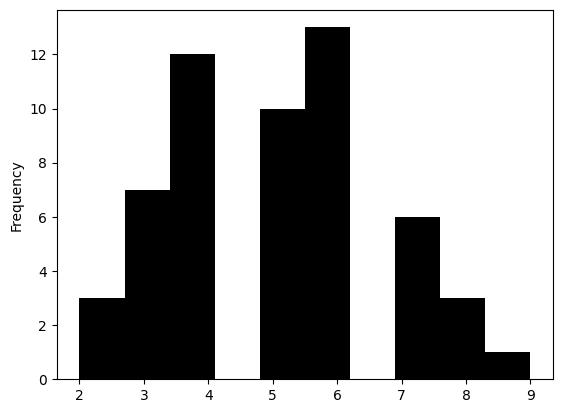

In [15]:
pd.Series(wq.cardinalities).plot.hist(color="k")

Este es un gráfico en el que se muestra, mediante conexiones, las vecindades de cada zona.

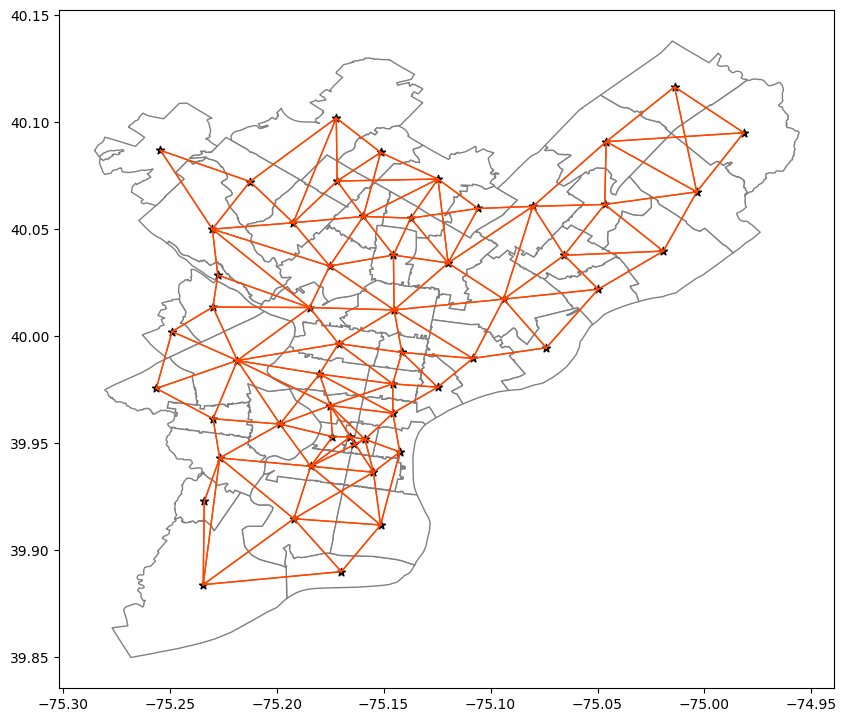

In [8]:
# Plot graph connections
ax = aggregate_df_train.plot(
        edgecolor="grey", facecolor="w",
        figsize=(10,10)
    )

wq.plot(
    aggregate_df_train,
    edge_kws=dict(linewidth=1, color="orangered"),
    node_kws=dict(marker="*"),
    ax=ax
)

plt.show()

## Retardos espaciales

Ahora se construira el retardo espacial para cada zona.

In [9]:
# Transformar pesos por filas
wq.transform = "R"

In [10]:
# Creación de variables con retardo espacial
aggregate_df_train["risk_score_lag"] = weights.spatial_lag.lag_spatial(
    wq, aggregate_df_train["risk_score"]
)

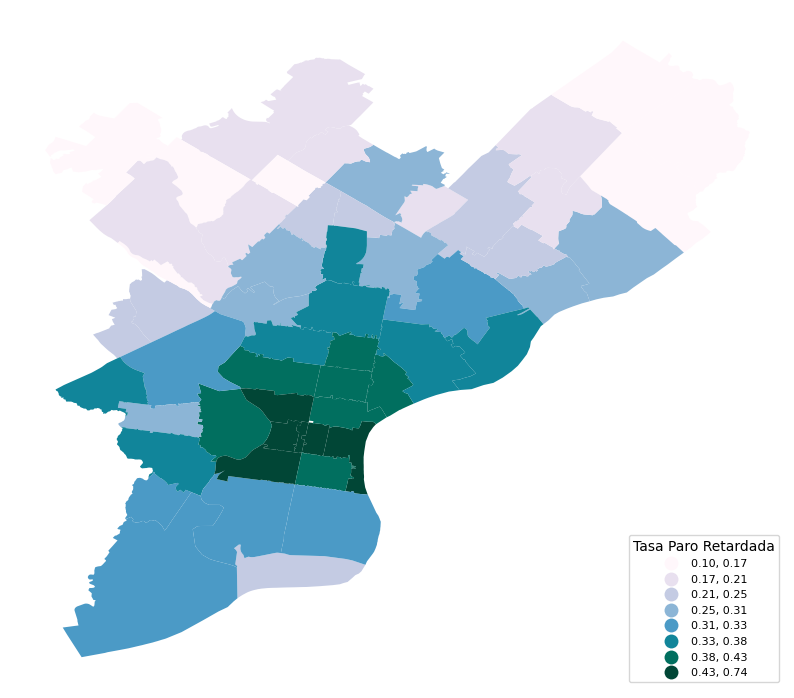

In [ ]:
# representación de la tasa de paro retardada
map=aggregate_df_train.plot(column='risk_score_lag', 
         scheme='quantiles',
         k=8, cmap='PuBuGn',
         legend=True,
         figsize=(10,10),
         legend_kwds={'loc': 'lower right', 'fontsize':'8', 'title':'Risk Score Retardada'} 
)
map.set_axis_off() 

## Autocorrelación Espacial

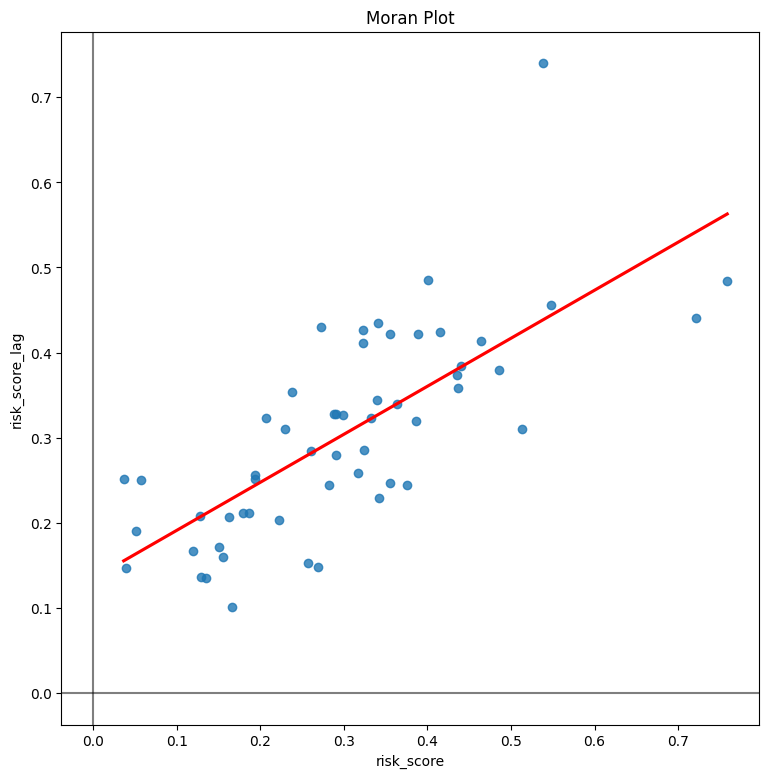

In [12]:
# AutoCorrelación Espacial
f, ax = plt.subplots(1, figsize=(9, 9))
sns.regplot(
    x="risk_score",
    y="risk_score_lag",
    ci=None,
    data=aggregate_df_train,
    line_kws={"color": "r"},
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_title("Moran Plot")
plt.show()

In [13]:
# Correlación Espacial: La I de Moran
moran = esda.moran.Moran(aggregate_df_train["risk_score"], wq)
print("I de moran:", moran.I.round(3))
print("p-valor:", moran.p_sim)

I de moran: 0.564
p-valor: 0.001


## Correlación Espacial Local

In [14]:
#Correlación Espacial Local
lisa = esda.moran.Moran_Local(aggregate_df_train["risk_score"], wq, seed=42)

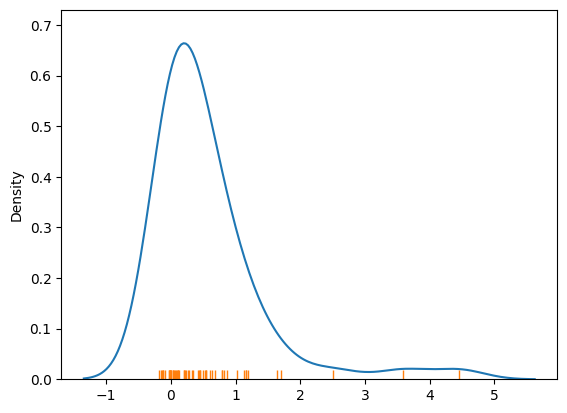

In [15]:
#Correlación Espacial Local
#Representación del Indice de Moran Local (Is)
# Draw KDE line
ax = sns.kdeplot(lisa.Is)
# Add one small bar (rug) for each observation
# along horizontal axis
sns.rugplot(lisa.Is, ax=ax);

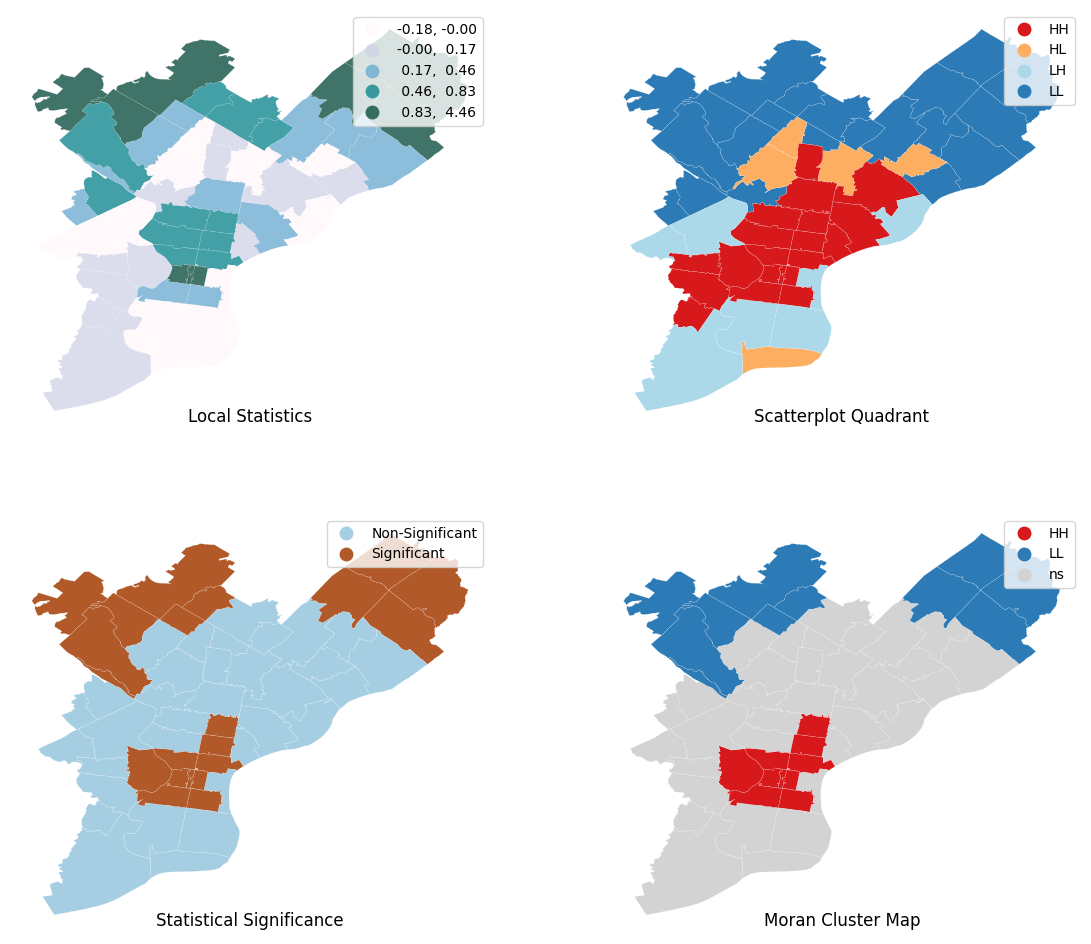

In [16]:
# Set up figure and axes
f, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
# Make the axes accessible with single indexing
axs = axs.flatten()

# Subplot 1 #
# Choropleth of local statistics
# Grab first axis in the figure
ax = axs[0]
# Assign new column with local statistics on-the-fly
aggregate_df_train.assign(
    Is=lisa.Is
    # Plot choropleth of local statistics
).plot(
    column="Is",
    cmap="PuBuGn",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.1,
    alpha=0.75,
    legend=True,
    ax=ax,
)

# Subplot 2 #
# Quadrant categories
# Grab second axis of local statistics
ax = axs[1]
# Plot Quandrant colors (note to ensure all polygons are assigned a
# quadrant, we "trick" the function by setting significance level to
# 1 so all observations are treated as "significant" and thus assigned
# a quadrant color
esdaplot.lisa_cluster(lisa, aggregate_df_train, p=1, ax=ax)

# Subplot 3 #
# Significance map
# Grab third axis of local statistics
ax = axs[2]
#
# Find out significant observations
labels = pd.Series(
    1 * (lisa.p_sim < 0.05),  # Assign 1 if significant, 0 otherwise
    index=aggregate_df_train.index  # Use the index in the original data
    # Recode 1 to "Significant and 0 to "Non-significant"
).map({1: "Significant", 0: "Non-Significant"})
# Assign labels to `db` on the fly
aggregate_df_train.assign(
    cl=labels
    # Plot choropleth of (non-)significant areas
).plot(
    column="cl",
    categorical=True,
    k=2,
    cmap="Paired",
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    ax=ax,
)


# Subplot 4 #
# Cluster map
# Grab second axis of local statistics
ax = axs[3]
# Plot Quandrant colors In this case, we use a 5% significance
# level to select polygons as part of statistically significant
# clusters
esdaplot.lisa_cluster(lisa, aggregate_df_train, p=0.05, ax=ax)

# Figure styling #
# Set title to each subplot
for i, ax in enumerate(axs.flatten()):
    ax.set_axis_off()
    ax.set_title(
        [
            "Local Statistics",
            "Scatterplot Quadrant",
            "Statistical Significance",
            "Moran Cluster Map",
        ][i],
        y=0,
    )
# Tight layout to minimise in-betwee white space
# f.tight_layout()

# Display the figure
plt.show()

In [17]:
# Assign pseudo P-values to `gdfm`
aggregate_df_train["p-sim"] = lisa.p_sim
# `1` if significant (at 5% confidence level), `0` otherwise
sig = 1 * (lisa.p_sim < 0.05)
# Assign significance flag to `db`
aggregate_df_train["sig"] = sig

# Pick as part of a quadrant only significant polygons,
# assign `0` otherwise (Non-significant polygons)
spots = lisa.q * sig
# Mapping from value to name (as a dict)
spots_labels = {
    0: "Non-Significant",
    1: "HH",
    2: "LH",
    3: "LL",
    4: "HL",
}
# Create column in `db` with labels for each polygon
aggregate_df_train["labels"] = pd.Series(
    # First initialise a Series using values and `db` index
    spots,
    index=aggregate_df_train.index
    # Then map each value to corresponding label based
    # on the `spots_labels` mapping
).map(spots_labels)
# Print top for inspection
aggregate_df_train["labels"].head(20)

0     Non-Significant
1     Non-Significant
2     Non-Significant
3                  LL
4     Non-Significant
5                  LL
6                  HH
7                  HH
8                  HH
9     Non-Significant
10                 HH
11                 HH
12    Non-Significant
13    Non-Significant
14                 LL
15                 LL
16                 LL
17                 LL
18    Non-Significant
19    Non-Significant
Name: labels, dtype: object

In [18]:
aggregate_df_train['labels'].value_counts()

labels
Non-Significant    33
LL                 11
HH                 11
Name: count, dtype: int64

In [19]:
# Procedemos a añadir la el risk score rezagado a la base original
aggregate_df_train_filter = aggregate_df_train[['ZCTA', 'risk_score_lag', 'sig', 'labels']]

In [20]:
# Procedemos a hacer merge con DF original
df_train_with_lag = df_train.merge(aggregate_df_train_filter, how= 'left', on='ZCTA')
df_train_with_lag.head(3)

,dc_dist,psa,date,hour,crime_description,time_of_day,day_of_week,week_of_year,month,season,...,household_25k_to_50k,household_50k_to_150k,household_150k_or_more,GiniIndex,risk_score,risk_level,geometry,risk_score_lag,sig,labels
0,16,1,2023-12-31,19,Thefts,Afternoon,Sunday,52,December,winter,...,22.5,32.9,8.7,0.5465,0.386350,Moderate,"POLYGON ((-75.21367 39.96003, -75.21204 39.959...",0.410693,1,HH
1,14,1,2023-12-31,19,Theft from Vehicle,Afternoon,Sunday,52,December,winter,...,20.5,45.4,5.6,0.4680,0.403469,Moderate,"POLYGON ((-75.17676 40.0502, -75.17515 40.0518...",0.228665,0,Non-Significant
2,25,1,2023-12-31,19,Other Assaults,Afternoon,Sunday,52,December,winter,...,26.8,29.9,3.6,0.5170,0.529389,High,"POLYGON ((-75.17036 40.00841, -75.16974 40.008...",0.373062,0,Non-Significant


In [21]:
# Lista de variables a borrar para mantener limpio el ambiente
variables_a_borrar = ['fig', 'var_name', 'axes', 'ax', 'axs', 'df_train', 'f', 'i', 'labels', 'lisa', 'map', 'moran', 'sig', 'spots', 'spots_labels', 'wq', 'var_name', 'df_train_raw' 'variables_a_borrar']
for var_name in variables_a_borrar:
   if var_name in globals():
       del globals()[var_name]

# Modelo XGBoost

In [22]:
# Carga de los datos 
train = gpd.GeoDataFrame(df_train_with_lag, geometry='geometry')
val = cleanDataframe2(df=gpd.read_file('../Input/ModelingDatasets/Validation/df_val_with_score_ZCTACoordinates.shp'))
test = cleanDataframe2(df=gpd.read_file('../Input/ModelingDatasets/Test/df_test_with_score_ZCTACoordinates.shp'))

# Se hace el merge con la variable risk_score_lag
val = val.merge(aggregate_df_train_filter, how= 'left', on='ZCTA')
test = test.merge(aggregate_df_train_filter, how='left', on='ZCTA')
# Se extraen de manera individual las coordenadas
test.head(3)

,dc_dist,psa,date,hour,crime_description,time_of_day,day_of_week,week_of_year,month,season,...,household_25k_to_50k,household_50k_to_150k,household_150k_or_more,GiniIndex,risk_score,risk_level,geometry,risk_score_lag,sig,labels
0,19,1,2025-05-01,0,Other Assaults,Night,Thursday,18,May,spring,...,21.3,44.1,11.0,0.4548,0.148727,Low,"POLYGON ((-75.28027 39.97496, -75.27951 39.975...",0.327737,0.0,Non-Significant
1,12,3,2025-05-01,0,Vandalism/Criminal Mischief,Night,Thursday,18,May,spring,...,30.1,35.5,3.2,0.4552,0.198018,Low,"POLYGON ((-75.24776 39.92171, -75.24769 39.921...",0.319057,0.0,Non-Significant
2,39,1,2025-05-01,0,Vandalism/Criminal Mischief,Night,Thursday,18,May,spring,...,23.3,30.0,4.2,0.5553,0.206633,Low,"POLYGON ((-75.19354 39.99624, -75.19332 39.996...",0.380033,0.0,Non-Significant


## Selección de variables

### Variables Numéricas

Primero se hace el análisis para aquellas variables que su información está agregada por código postal (ZCTA). Todas de ellas son numéricas así que de paso se utilizará la variable risk_score para poder distinguir relaciones de manera más visual utilizando scatterplots.

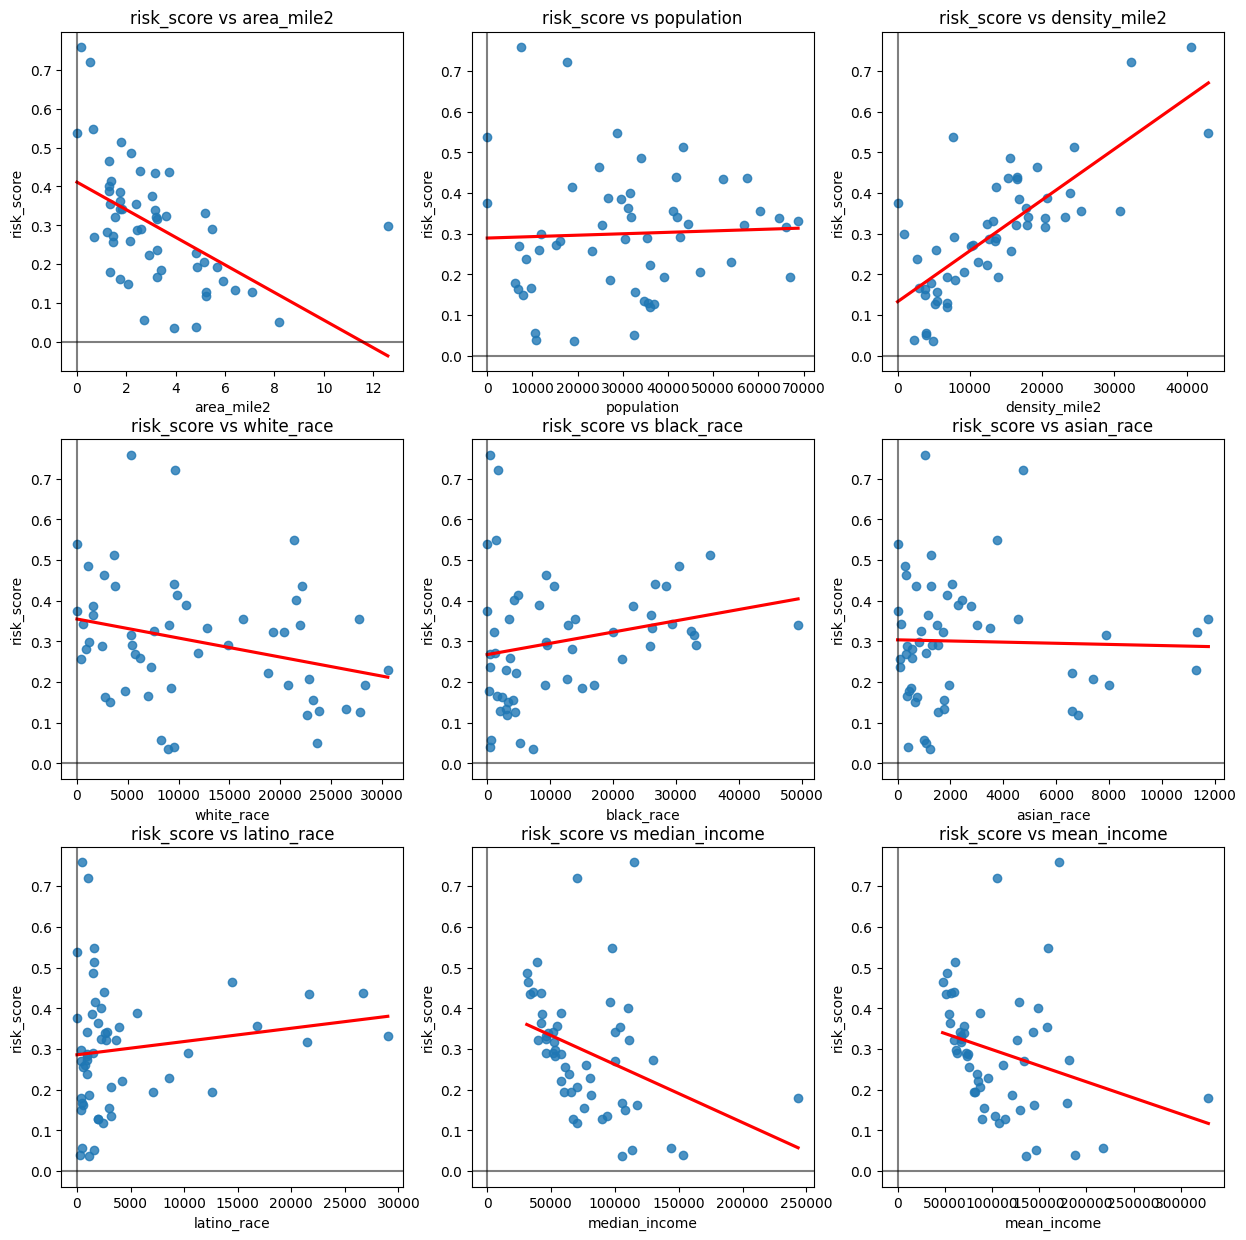

In [23]:
# Variables explicativas
x_vars = [
    'area_mile2', 'population', 'density_mile2', 
    'white_race', 'black_race', 'asian_race', 
    'latino_race','median_income', 'mean_income'
]

# Crear la figura con subplots en forma de 3x3
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()  # aplanar para indexar fácilmente

# Loop para crear cada gráfico
for i, x_var in enumerate(x_vars):
    sns.regplot(
        x=x_var,
        y="risk_score",
        data=aggregate_df_train,
        ci=None,
        line_kws={"color": "r"},
        ax=axes[i]
    )
    axes[i].axhline(0, c="k", alpha=0.5)
    axes[i].axvline(0, c="k", alpha=0.5)
    axes[i].set_title(f"risk_score vs {x_var}")

Esto nos graficos de dispersión nos dan una idea respecto a cuales variables presentan una relación, ya sea positiva o negativa, o en todo caso, que no presente relación del todo. Algunos insights son:

- Relación negativa entre área de la zona ZCTA y el risk score.
- La población no parece tener un relación clara con el risk score; por otra parte, la densidad poblacional sí denota una relación positiva clara. Esto podría estar ligado a la misma área de la zona, ya que vimos que entre más pequeña el área, se presenta un score más alto pero a la vez, esas mismas zonas con menos áreas suelen presentar densidades poblacionales mayores.
- Con el tema de las población por raza se distinguen varios hallazgos:
    - Entre mayor es la cantidad sea persona blancas, se tiende a tener score más bajos.
    - De forma inversa pasa con los latinos y las personas negras
    - Con la población asiática, realmente no se distingue un patrón claro por lo que se descartarán.
    - A modo de conclusión, se creará una variable que unifique la población negra con la latina y la población blanca de mantendrá por aparte.
- Tanto con la media y mediana del ingreso muestran una asociación negativa con el risk score por lo que para efectos del cálculo. Acá cabe resaltar que curiosamente las áreas que presentan el mayor ingreso, son también las que presentan el mayor índice de riesgo. 



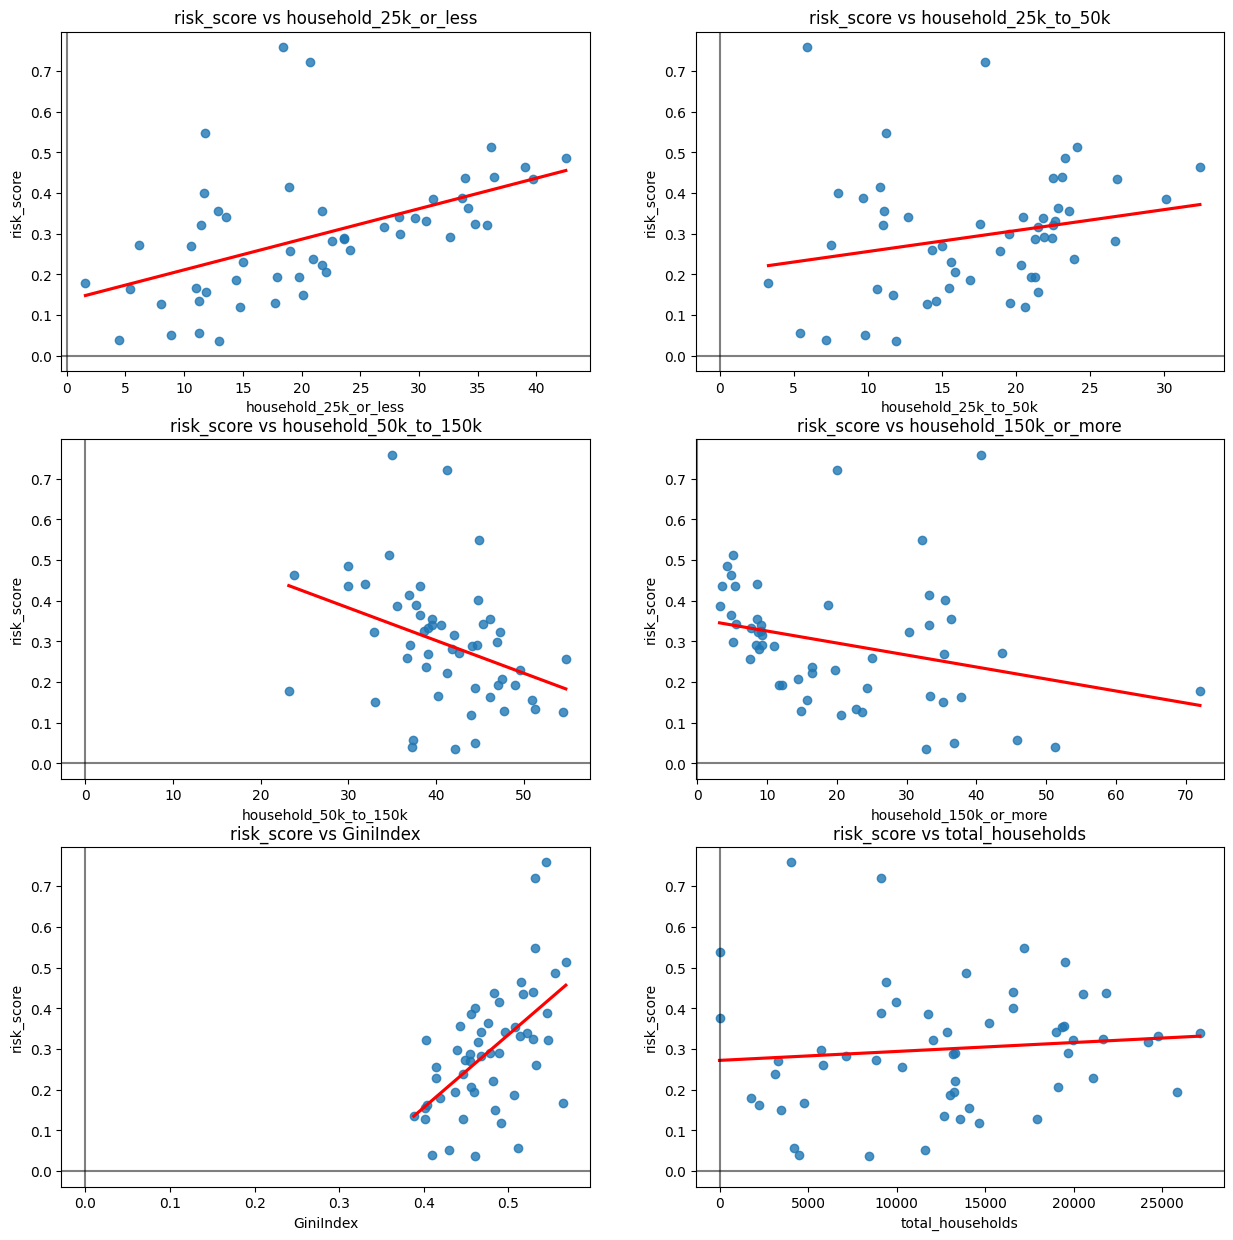

In [24]:
# Variables que irán en X
x_vars = [
    'household_25k_or_less', 'household_25k_to_50k', 'household_50k_to_150k', 
    'household_150k_or_more', 'GiniIndex', 'total_households'
]

# Crear la figura con subplots en forma de 3x3
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()  # aplanar para indexar fácilmente

# Loop para crear cada gráfico
for i, x_var in enumerate(x_vars):
    sns.regplot(
        x=x_var,
        y="risk_score",
        data=aggregate_df_train,
        ci=None,
        line_kws={"color": "r"},
        ax=axes[i]
    )
    axes[i].axhline(0, c="k", alpha=0.5)
    axes[i].axvline(0, c="k", alpha=0.5)
    axes[i].set_title(f"risk_score vs {x_var}")

Las siguiente variables también nos dan insights muy interesantes:

- Los primeros cuatro gráficos son relacionados al porcentaje (%) de households que presentan los diferentes rango de ingresos y notamos un patrón muy claro. 
    - Para aquellos hogares que presentan un ingreso anual menor a los 25k dólares, hay una clara asociación positiva, es decir, entre más crece el porcentaje de hogares con este ingreso anual, el índice tiende a crecer.
    - Esta dinámica se mantiene para el rango de los 25k a los 50k dólares, pero en menor medida.
    - Para cuando llegamos al tercer rango, la asociación se invierte, es decir, entre más crece el % de hogares en este rango de ingreso, el score se reduce.
    - De manera análoga sucede para el último rango de ingresos.
- Por otro lado, el índice de Gini muestra una muy clara relación positiva lo cual hace mucho sentido social, entre mayor sea la disparidad de ingresos en una zona, mayor peligro presentará.
- Por último, tenemos la relación entre el risk score y la cantidad de hogares que su gráfico de dispersión no muestra una asociación entre ambas.

Acabamos de analizar todas aquellas variables cuya información estaba por zona postal y se procederá a eliminar aquellas que para efectos de este primer acercamiento exploratorio no han mostrado tener una relación directa con la variable objetivo. Estas son:

- Área, población y densidad: a pesar de que el área y la densidad sí presentaron una relación clara, la misma está explicada por el hecho de que fueron utilizadas para la construcción del índice por lo que no tiene sentido y estariamos incurriendo en data leakage.
- La población asiática se descartara, y la población negra y latina se unificarán en una sola variable. Además, consideraremos estas variable poblacionales como el % de dicha raza que habita en esa zona y no en términos absolutos. 
- La mediana y media del ingreso mostraron una relación muy consistente entre ambos, por lo que para efectos del modelado solo se tomará la mediana y se descarta el promedio.
- La cantidad de hogares (households) también se procederá a descartarla.

In [25]:
train['white_race'] = train['white_race']/train['population']
train['others_races'] = (train['black_race'] + train['latino_race'])/train['population']

val['white_race'] = val['white_race']/val['population']
val['others_races'] = (val['black_race'] + val['latino_race'])/val['population']

test['white_race'] = test['white_race']/test['population']
test['others_races'] = (test['black_race'] + test['latino_race'])/test['population']

In [26]:

# Se eliminan variables que a priori no se utilizaran (Se eliminan adicionalmente la geometría, el risk score y el risk label)
drop_cols = ['area_mile2', 'population', 'density_mile2', 'black_race', 'asian_race', 'latino_race', 'mean_income', 'total_households']
X_train_model_v1 = train.drop(columns=drop_cols, errors='ignore')
X_valid_model_v1 = val.drop(columns=drop_cols, errors='ignore')
X_test_model_v1 = test.drop(columns=drop_cols, errors='ignore')

In [27]:
X_valid_model_v1.columns

Index(['dc_dist', 'psa', 'date', 'hour', 'crime_description', 'time_of_day',
       'day_of_week', 'week_of_year', 'month', 'season', 'is_holiday',
       'crimeType', 'ZCTA', 'white_race', 'median_income',
       'household_25k_or_less', 'household_25k_to_50k',
       'household_50k_to_150k', 'household_150k_or_more', 'GiniIndex',
       'risk_score', 'risk_level', 'geometry', 'risk_score_lag', 'sig',
       'labels', 'others_races'],
      dtype='object')

## Variables categóricas

Ahora procederemos a analizar la relación que existe con aquellas variables que no están agrupadas por área. Para este enfoque, dado que la mayoría de estas variables son categorícas, se podrá utilizar también el risk level. Al final tanto el risk score como el risk label son diferentes representaciones de un mismo concepto y al hacer la comparación entre dos variables categóricas nos podemos apoyar de herramientas como el test chi cuadrado.

In [28]:
# Analizamos la cardinalidad
lista_cat = [
    'dc_dist', 'psa', 'hour', 'time_of_day',
    'day_of_week', 'week_of_year', 'month', 'season', 
    'is_holiday','ZCTA', 'sig', 'labels'
]

train[lista_cat].nunique().sort_values(ascending = False)

ZCTA            55
week_of_year    52
hour            24
dc_dist         22
month           12
day_of_week      7
psa              6
season           4
time_of_day      3
labels           3
is_holiday       2
sig              2
dtype: int64

### Variable: hour

Notamos que la mayoría de crímenes sucenden durante el día, puntualmente entre 10am y las 6pm, lo cual hace sentido porque justamente es en estas horas donde hay mayor actividad poblacional.

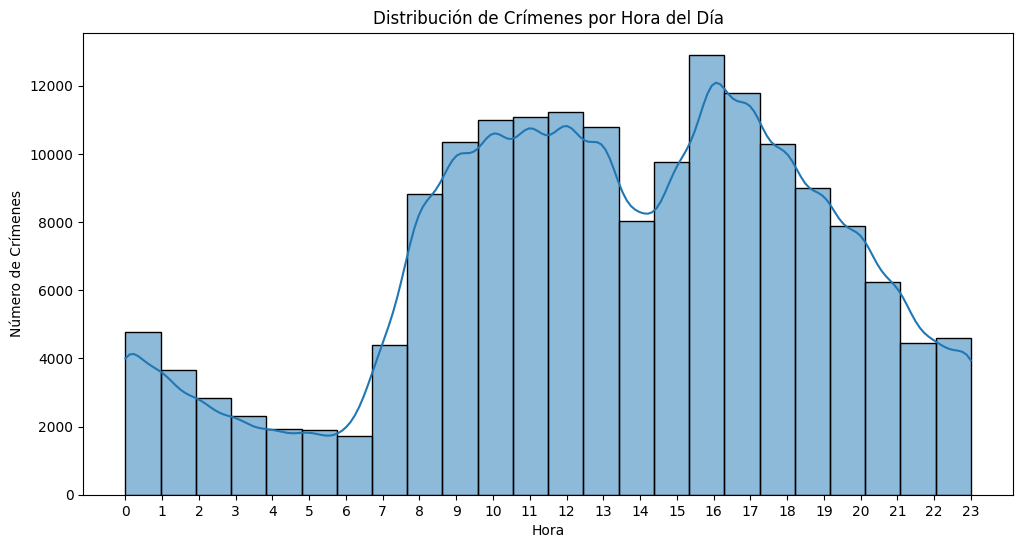

In [38]:
plt.figure(figsize=(12, 6))
sns.histplot(data=train, x='hour', bins=24, kde=True)
plt.title('Distribución de Crímenes por Hora del Día')
plt.xlabel('Hora')
plt.ylabel('Número de Crímenes')
plt.xticks(range(0, 24))
plt.show()

Comprobemos la relación de la hora del día con el risk score y el risk level.

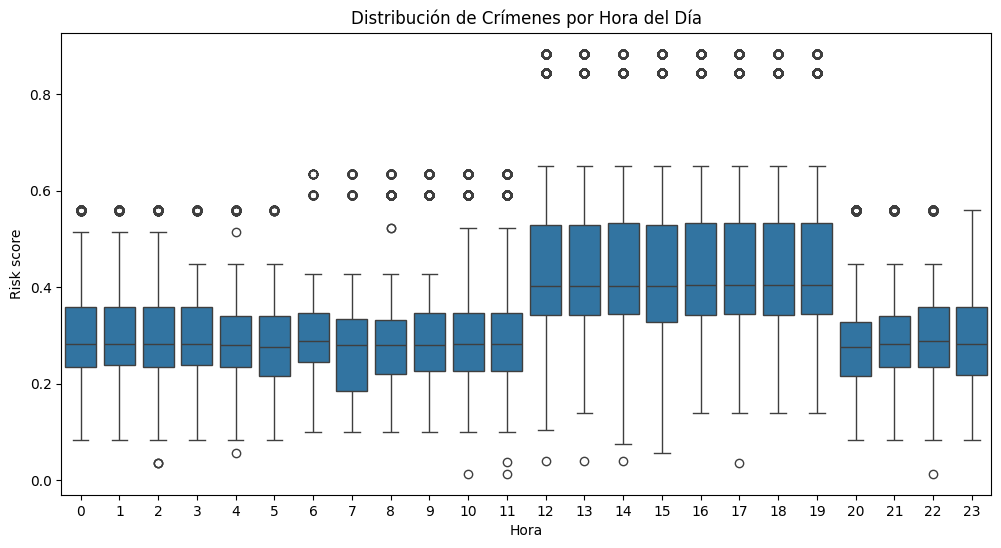

In [39]:
# Se compara con el risk score mediante un boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=train, x='hour', y = 'risk_score')
plt.title('Distribución de Crímenes por Hora del Día')
plt.xlabel('Hora')
plt.ylabel('Risk score')
plt.xticks(range(0, 24))
plt.show()

Y ahora con el risk level, mediante tablas de contingencia y calculando la V de Crámer. 

In [40]:
chi2_cramersv(df = train, target='risk_level', cat_vars=['hour'])

,variable,p_value,cramers_v
0,hour,0.0,0.300746


La hora del día muestra una asociación moderado con el risk level. Analizándola tanto con el risk score como con su contraparte categórica, la conclusión es que hay evidencia para utilizarla como covariable en el estudio.

### Variable: time of day

Es una variable que sirve para reducir la cardinalidad de la variable 'hour'. El siguiente paso sería determinar si aportaría valor predictivo al mismo nivel que hour.

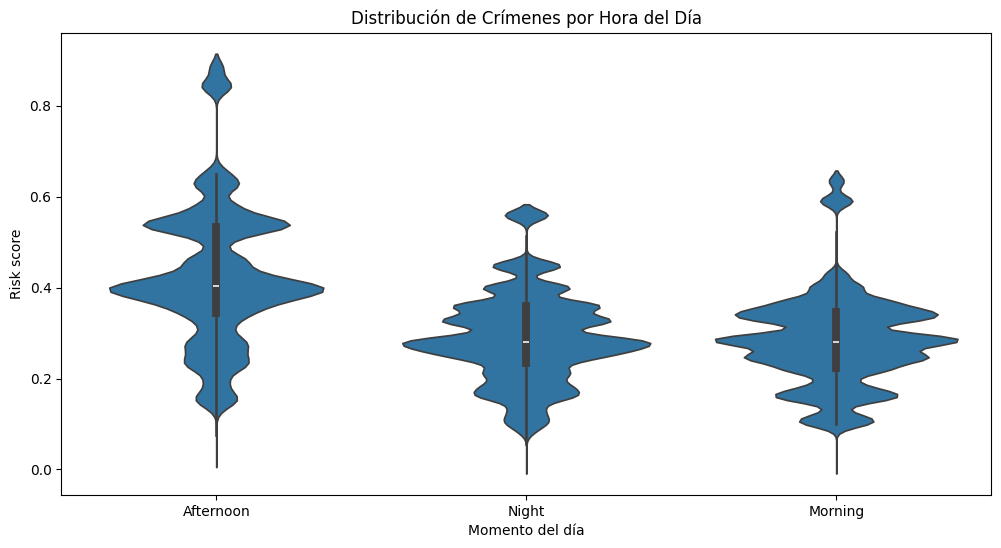

In [41]:
# Se compara con el risk score mediante un boxplot
plt.figure(figsize=(12, 6))
sns.violinplot(data=train, x='time_of_day', y = 'risk_score')
plt.title('Distribución de Crímenes por Hora del Día')
plt.xlabel('Momento del día')
plt.ylabel('Risk score')
plt.show()

El gráfico se alínea con lo que ya habíamos encontrado. Realmente sería comprobar si aporta valor agregado mediante la V de Cramer.

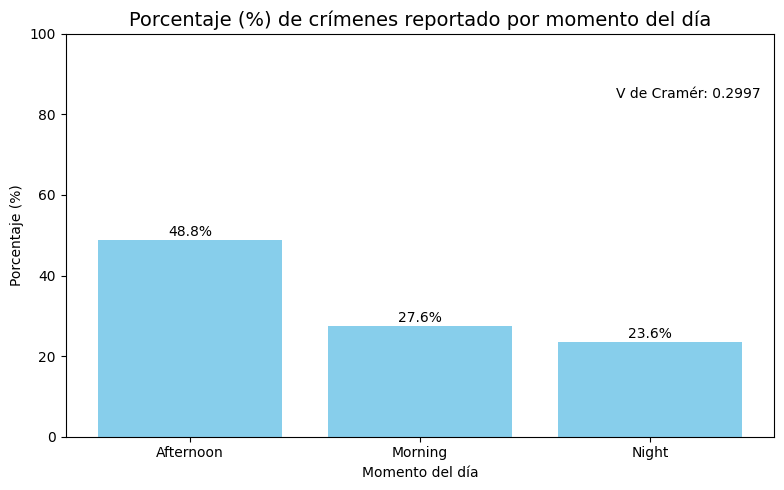

In [42]:
# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['time_of_day'])
# Porcentajes
counts = train['time_of_day'].value_counts(normalize=True) * 100

# Crear gráfico
plt.figure(figsize=(8,5))
bars = plt.bar(counts.index, counts.values, color='skyblue')
plt.title('Porcentaje (%) de crímenes reportado por momento del día', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Momento del día')
plt.ylim(0, 100)
# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10)
# Añadir texto V de Cramér
plt.text(1.85, 84, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10)
plt.tight_layout()
plt.show()

En efecto, la V de Cramer es de 0.297, se sigue manteniendo una asociación moderado pero con una reducción de la cardinalidad bastante importante por lo que se preferirá esta variable sobre 'hour'.

### Variable: dc_dist

Si calculamos la V de Cramer así como viene el dato, tendríamos:

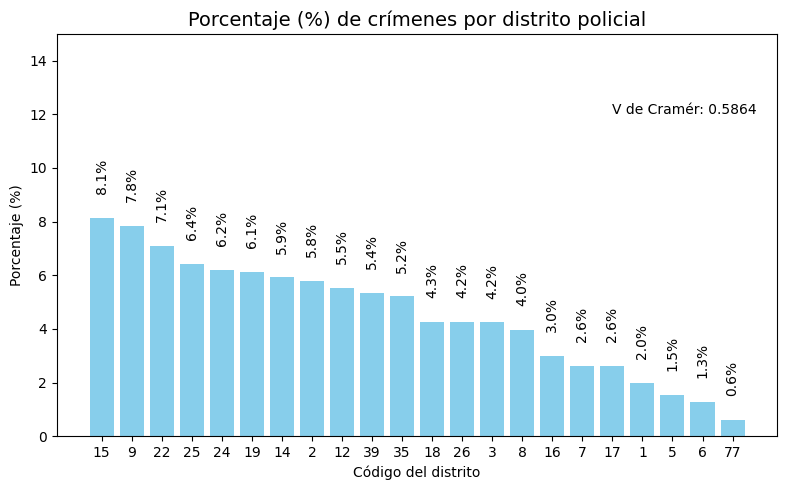

In [29]:
# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['dc_dist'])

# Porcentajes
counts = train['dc_dist'].value_counts(normalize=True) * 100

# Crear gráfico
plt.figure(figsize=(8,5))
bars = plt.bar(counts.index.astype(str), counts.values, color='skyblue')  # ← Convertir a string
plt.title('Porcentaje (%) de crímenes por distrito policial', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Código del distrito')
plt.ylim(0, 15)
# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10, rotation=90)
# Añadir texto V de Cramér
plt.text(len(counts)-5, 12, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10)
plt.tight_layout()
plt.show()

La cardinalidad es muy alta, lo ideal sería reducirla y para ello analicemos si existe cierta relación entre el código del distrito y el risk score:

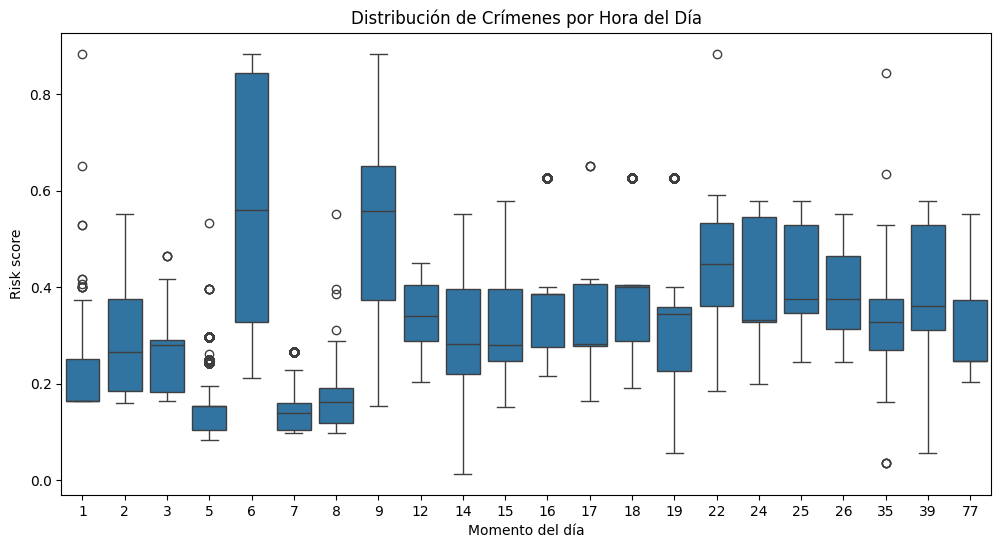

In [30]:
# Se compara con el risk score mediante un boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=train, x='dc_dist', y = 'risk_score')
plt.title('Distribución de Crímenes por Hora del Día')
plt.xlabel('Momento del día')
plt.ylabel('Risk score')
plt.show()

Llama bastante la atención que los distritos 6 y 9 presentan una variabilidad bastante considerable comparado con los demás, llegando a alcanzar risk scores de hasta 0.8 sin considerarse outliers. Y si nos vamos al primer gráfico, el distrito policial 9 es el segundo con mayor incidencia de crímenes y por otro lado, al 6 le pasa totalmente lo opuesto, siendo el penúlitmo.

A la hora de agrupar sería de importancia unir aquellas categorías que presenten este tipo de similitudes por lo que la reducción de la cardinalidad será con base en el promedio de de la variable target.

In [32]:
# Se procederá a hacer una agrupación con base en la media de nuestra variable target
target_mean = train.groupby('dc_dist')['risk_score'].agg(['mean']).reset_index().sort_values(by = 'mean', ascending=False)

thresholds = {
    'Alto': 0.4,     # >= 0.4
    'Moderado': 0.3, # 0.25 - 0.4
    'Bajo': 0.2, 
    'Muy Bajo': 0.10      # < 0.15
}

# La lógica de agrupación 
def categorizar_dc_dist(mean_value):
    if mean_value >= thresholds['Alto']:
        return 'Alto'
    elif mean_value >= thresholds['Moderado']:
        return 'Moderado'
    elif mean_value >= thresholds['Bajo']:
        return 'Bajo'
    else:
        return 'Muy Bajo'
    
# Se crea nueva columna 
target_mean['dc_dist_grouped'] = target_mean['mean'].apply(categorizar_dc_dist)

In [33]:
# Merge con la data inicial
train = train.merge(target_mean[['dc_dist', 'dc_dist_grouped']], how='left', on = 'dc_dist')
val = val.merge(target_mean[['dc_dist', 'dc_dist_grouped']], how='left', on = 'dc_dist')
test = test.merge(target_mean[['dc_dist', 'dc_dist_grouped']], how='left', on = 'dc_dist')

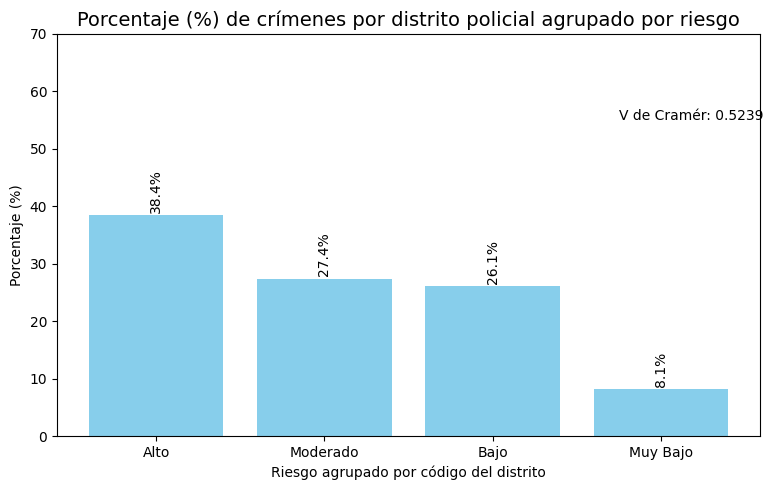

In [34]:
# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['dc_dist_grouped'])

# Porcentajes
counts = train['dc_dist_grouped'].value_counts(normalize=True) * 100

# Crear gráfico
plt.figure(figsize=(8,5))
bars = plt.bar(counts.index.astype(str), counts.values, color='skyblue')  # ← Convertir a string
plt.title('Porcentaje (%) de crímenes por distrito policial agrupado por riesgo', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Riesgo agrupado por código del distrito')
plt.ylim(0, 70)
# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10, rotation=90)
# Añadir texto V de Cramér
plt.text(len(counts)-1.25, 55, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10)
plt.tight_layout()
plt.show()

### Variable: psa

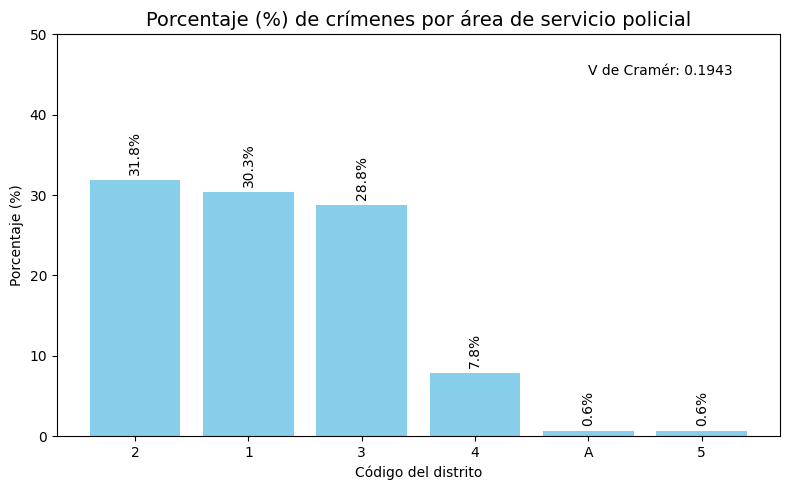

In [47]:
# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['psa'])

# Porcentajes
counts = train['psa'].value_counts(normalize=True) * 100

# Crear gráfico
plt.figure(figsize=(8,5))
bars = plt.bar(counts.index.astype(str), counts.values, color='skyblue')  # ← Convertir a string
plt.title('Porcentaje (%) de crímenes por área de servicio policial', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Código del distrito')
plt.ylim(0, 50)
# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10, rotation=90)
# Añadir texto V de Cramér
plt.text(len(counts)-2.0, 45, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10)
plt.tight_layout()
plt.show()

Hay 3 categorías muy poco representadas. Veamos como se comporta el gráfico de violin.

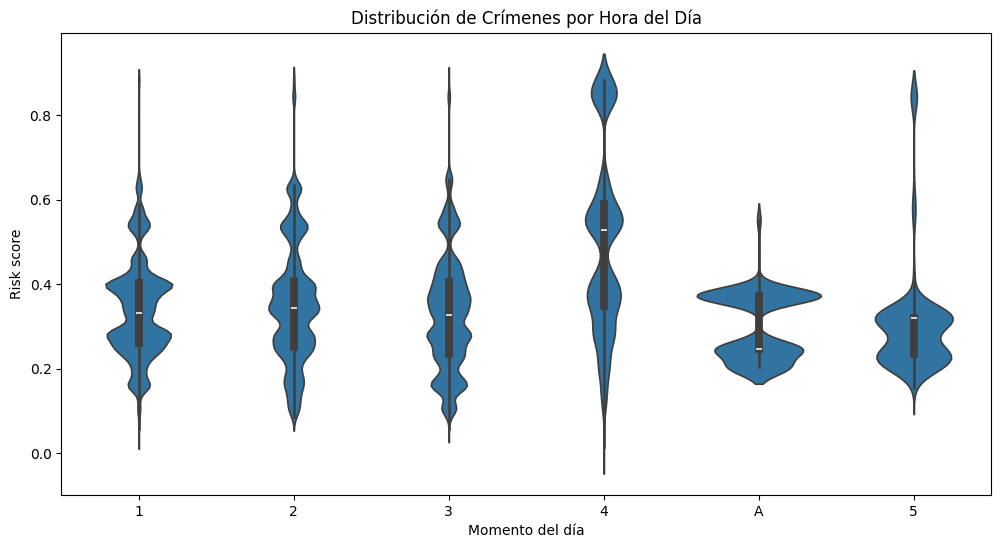

In [48]:
# Se compara con el risk score mediante un boxplot
plt.figure(figsize=(12, 6))
sns.violinplot(data=train, x='psa', y = 'risk_score')
plt.title('Distribución de Crímenes por Hora del Día')
plt.xlabel('Momento del día')
plt.ylabel('Risk score')
plt.show()

El área 4 y 5 son las que presentan las colas más largas. Veamos como se comporta la media de la variable target a través de los grupos:

In [49]:
# Se procederá a hacer una agrupación con base en la media de nuestra variable target
target_mean = train.groupby('psa')['risk_score'].agg(['mean']).reset_index().sort_values(by = 'mean', ascending=False)
target_mean


,psa,mean
3,4,0.496371
1,2,0.351954
0,1,0.342179
2,3,0.332012
4,5,0.301455
5,A,0.300183


Como se nota en la tabla, sí hay un tema con el psa 4 en donde su índice de riesgo promedio es casi 0.5. Sin embargo, la variabilidad respecto a mis otras categorías es muy baja como para aplicar lo que se hizo para dc_dist. Asimismo, las categorías 4 y 5 son las que presentan las colas largas más pronunciadas, así que para efectos de reducir cardinalidad, se unificaran las categorías 4, 5 y A.

In [50]:
# Definir las categorías poco frecuentes
categorias_por_agrupar = ['4', '5', 'A']  # OJO: revisa si 'dc_dist' es string o numérico

# Crear nueva columna agrupada
train['psa_grouped'] = train['psa'].replace(categorias_por_agrupar, '4')

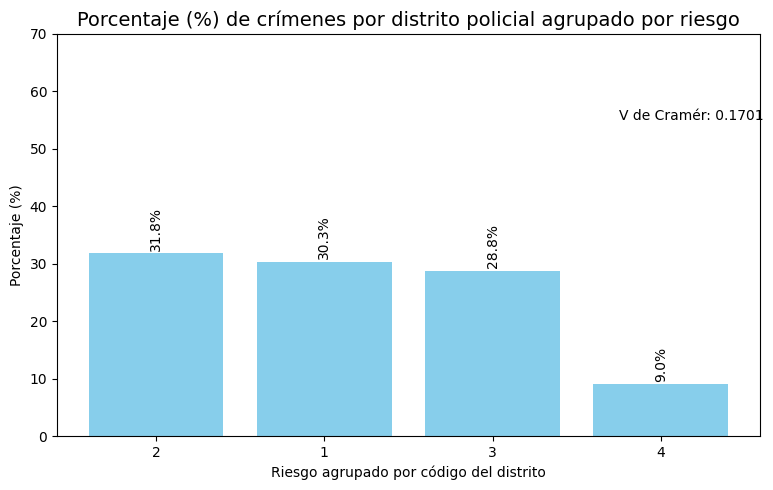

In [51]:
# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['psa_grouped'])

# Porcentajes
counts = train['psa_grouped'].value_counts(normalize=True) * 100

# Crear gráfico
plt.figure(figsize=(8,5))
bars = plt.bar(counts.index.astype(str), counts.values, color='skyblue')  # ← Convertir a string
plt.title('Porcentaje (%) de crímenes por distrito policial agrupado por riesgo', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Riesgo agrupado por código del distrito')
plt.ylim(0, 70)
# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10, rotation=90)
# Añadir texto V de Cramér
plt.text(len(counts)-1.25, 55, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10)
plt.tight_layout()
plt.show()

La asociación incluso bajo un poco más. A priori no se considerará en el set inicial de variables para modelar pero es tentivo su uso.

### Variable: month

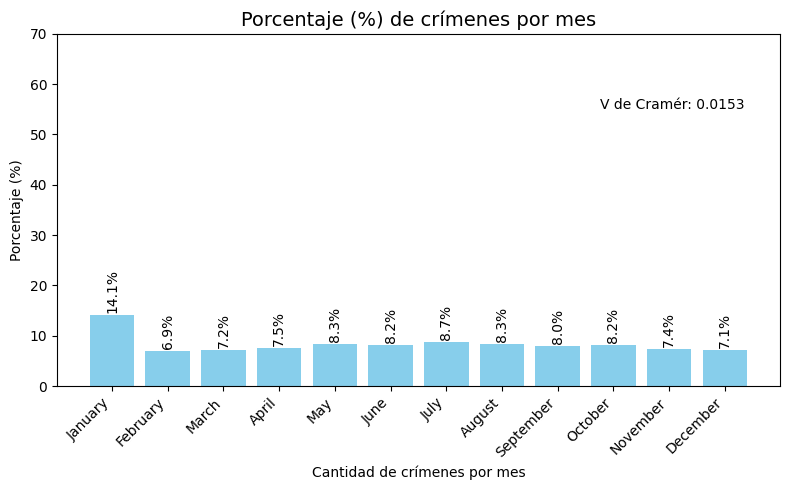

In [52]:
# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['month'])

order = list(calendar.month_name)[1:]

# Porcentajes
counts = train['month'].value_counts(normalize=True) * 100
counts = counts.reindex(order).dropna()

# Crear gráfico
plt.figure(figsize=(8,5))
bars = plt.bar(counts.index, counts.values, color='skyblue')  # ← Convertir a string
plt.title('Porcentaje (%) de crímenes por mes', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Cantidad de crímenes por mes')
plt.ylim(0, 70)
plt.xticks(rotation=45, ha='right')
# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10, rotation=90)
# Añadir texto V de Cramér
plt.text(len(counts)-3.25, 55, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10,)
plt.tight_layout()
plt.show()

Desde un punto de vista absoluto, sí hay una incidencia mayor de crímenes en el mes de enero. Sin embargo, hay que tomar en cuenta que nuestra base de entrenamiento llega hasta enero 2025 por lo que era de esperarse que hayan más. Este gráfico realmente no nos revela información importante, más bien nos puede inducir al error. Lo que sí podríamos usar para determinar si hay cierto patrón cíclico sería viendo su distribución respecto al riskscore. 

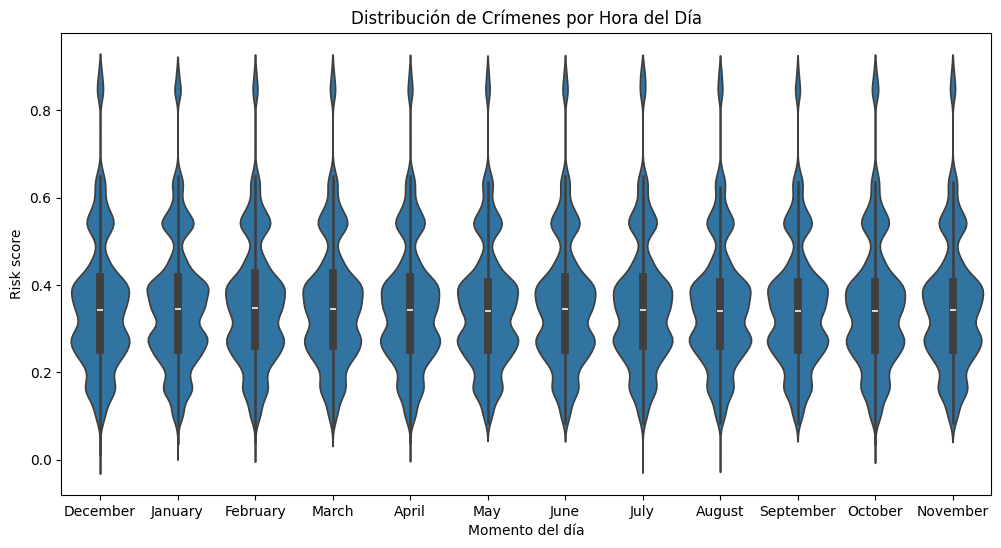

In [53]:
# Se compara con el risk score mediante un boxplot
plt.figure(figsize=(12, 6))
sns.violinplot(data=train, x='month', y = 'risk_score')
plt.title('Distribución de Crímenes por Hora del Día')
plt.xlabel('Momento del día')
plt.ylabel('Risk score')
plt.show()

La distribución en todos los meses se mantiene relativamente estable. Esto combinado a su poca asociación arrojada por la V de Cramer, llegamos a la conclusión de que realmente no es una variable que aportaría poder predictivo.

### Variable: season

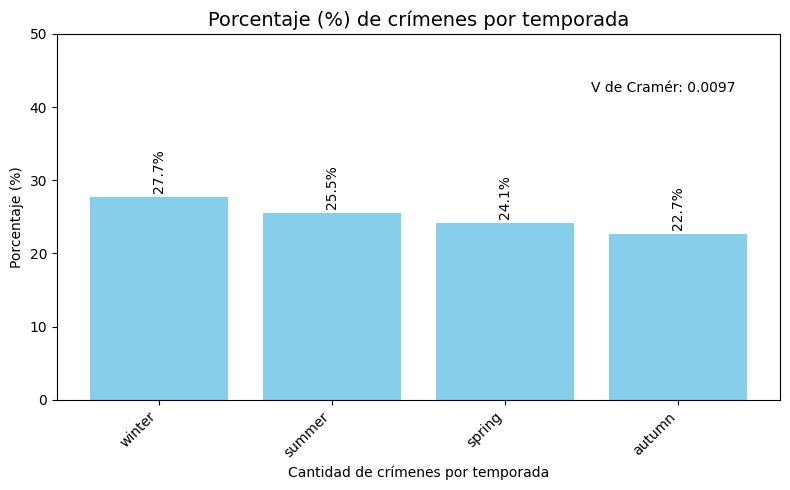

In [54]:
# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['season'])

# Porcentajes
counts = train['season'].value_counts(normalize=True) * 100

# Crear gráfico
plt.figure(figsize=(8,5))
bars = plt.bar(counts.index, counts.values, color='skyblue')  # ← Convertir a string
plt.title('Porcentaje (%) de crímenes por temporada', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Cantidad de crímenes por temporada')
plt.ylim(0, 50)
plt.xticks(rotation=45, ha='right')
# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10, rotation=90)
# Añadir texto V de Cramér
plt.text(len(counts)-1.50, 42, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10,)
plt.tight_layout()
plt.show()

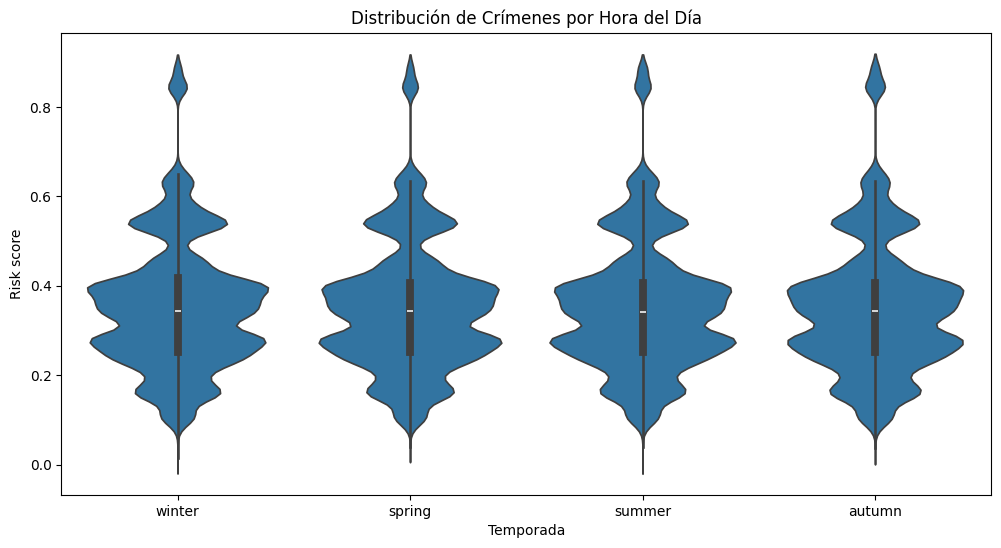

In [55]:
# Se compara con el risk score mediante un boxplot
plt.figure(figsize=(12, 6))
sns.violinplot(data=train, x='season', y = 'risk_score')
plt.title('Distribución de Crímenes por Hora del Día')
plt.xlabel('Temporada')
plt.ylabel('Risk score')
plt.show()

De ambos gráficos lo que podemos concluir es que realmente no existe una asociación muy clara entre la cantidad de crímenes y la temporada del año y sus distribuciones son bastantes consistentes entre sí. Se descarta la variable a priori.

### Variable: is_holiday

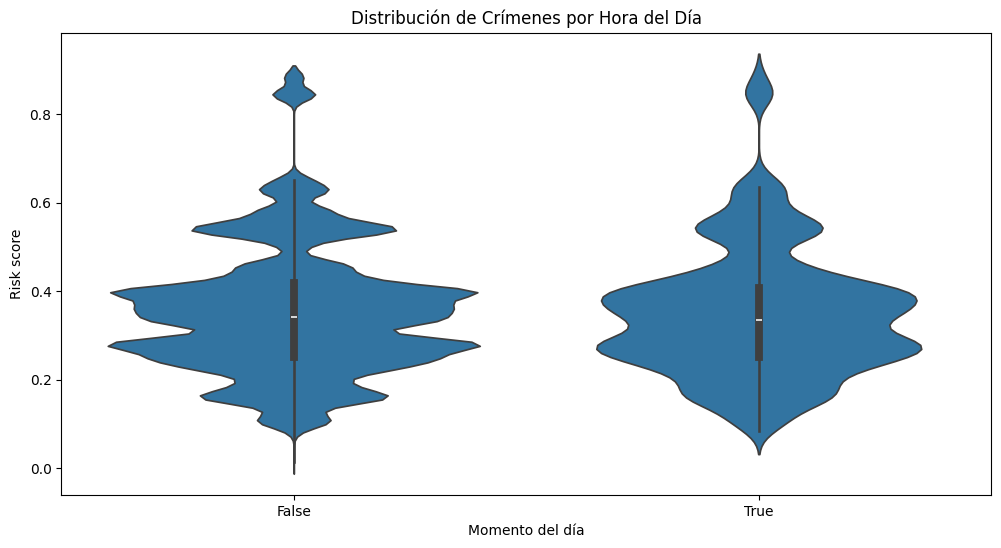

In [56]:
# Se compara con el risk score mediante un boxplot
plt.figure(figsize=(12, 6))
sns.violinplot(data=train, x='is_holiday', y = 'risk_score')
plt.title('Distribución de Crímenes por Hora del Día')
plt.xlabel('Momento del día')
plt.ylabel('Risk score')
plt.show()

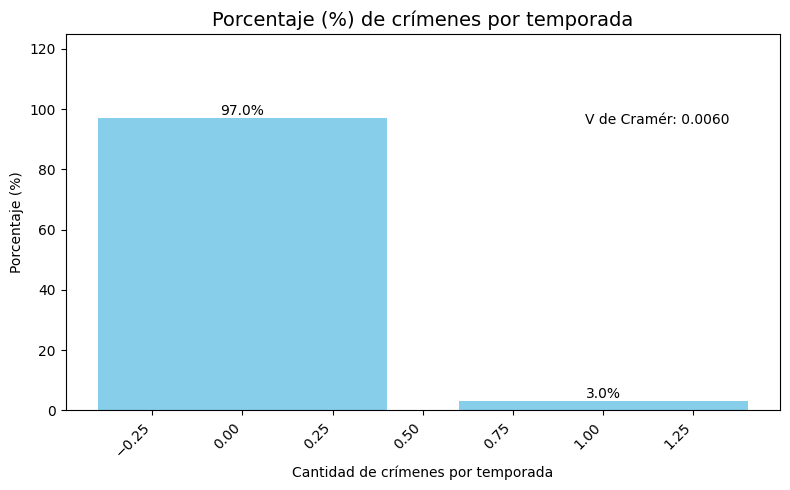

In [57]:
# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['is_holiday'])

# Porcentajes
counts = train['is_holiday'].value_counts(normalize=True) * 100

# Crear gráfico
plt.figure(figsize=(8,5))
bars = plt.bar(counts.index, counts.values, color='skyblue')  # ← Convertir a string
plt.title('Porcentaje (%) de crímenes por temporada', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Cantidad de crímenes por temporada')
plt.ylim(0, 125)
plt.xticks(rotation=45, ha='right')
# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10)
# Añadir texto V de Cramér
plt.text(len(counts)-1.05, 95, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10,)
plt.tight_layout()
plt.show()

Es una variable categórica que está muy desbalanceada. Siguiendo la regla empírica de que tener categorías tan poco representadas (3%) puede llegar a ser más contraproducente así que se descarta.

### Variable: week day

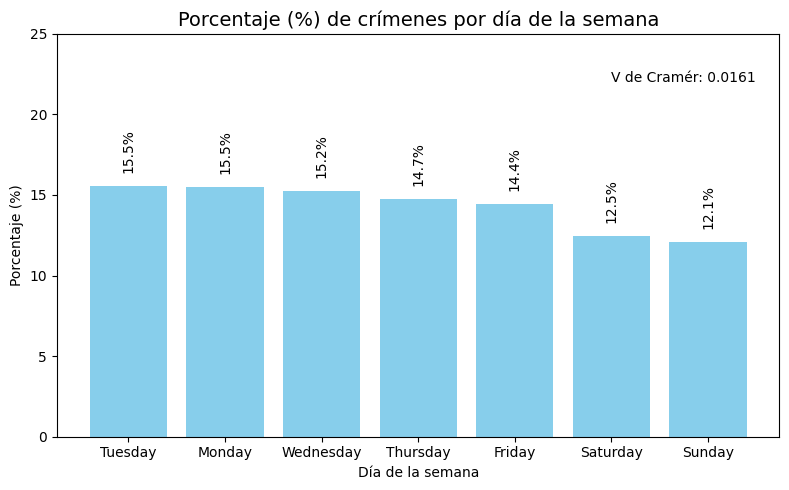

In [59]:
# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['day_of_week'])

# Porcentajes
counts = train['day_of_week'].value_counts(normalize=True) * 100

# Crear gráfico
plt.figure(figsize=(8,5))
bars = plt.bar(counts.index.astype(str), counts.values, color='skyblue')  # ← Convertir a string
plt.title('Porcentaje (%) de crímenes por día de la semana', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Día de la semana')
plt.ylim(0, 25)
# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10, rotation=90)
# Añadir texto V de Cramér
plt.text(len(counts)-2, 22, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10)
plt.tight_layout()
plt.show()

La V de Cramer muestra una asociación muy baja pero un patrón que sí se observa es que los fines de semana tienden a tener menos crímenes por lo que haremos un intento de agrupamiento mediante una variable dummie de si el día es entre semana o fin de semana, para comprobar si esto aumenta la asociación con mi variable objetivo.

In [60]:
weekend_days = ['Saturday', 'Sunday']
train['is_weekend'] = train['day_of_week'].isin(weekend_days).astype(int)

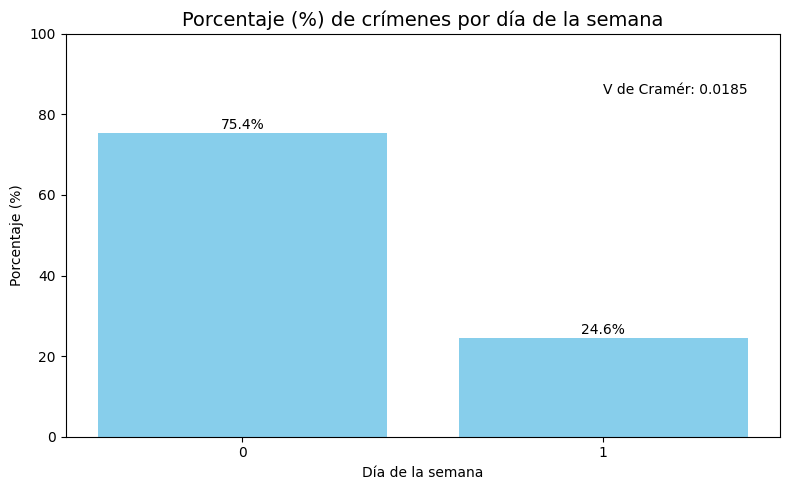

In [61]:
# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['is_weekend'])

# Porcentajes
counts = train['is_weekend'].value_counts(normalize=True) * 100

# Crear gráfico
plt.figure(figsize=(8,5))
bars = plt.bar(counts.index.astype(str), counts.values, color='skyblue')  # ← Convertir a string
plt.title('Porcentaje (%) de crímenes por día de la semana', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Día de la semana')
plt.ylim(0, 100)
# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10)
# Añadir texto V de Cramér
plt.text(len(counts)-1, 85, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10)
plt.tight_layout()
plt.show()

La asociación incrementó muy poco, es una variable que aportaría poco.

### Variabl: sig 

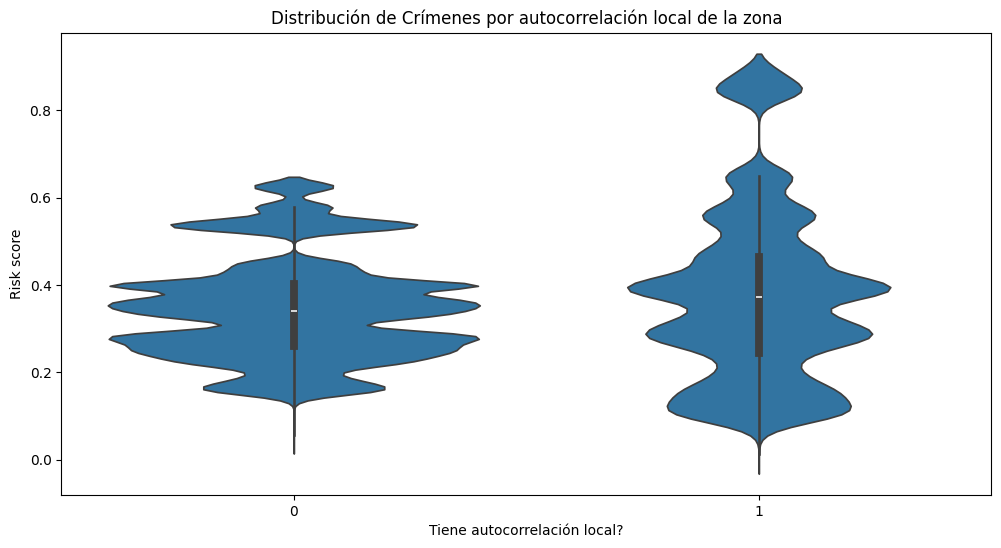

In [62]:
# Se compara con el risk score mediante un boxplot
plt.figure(figsize=(12, 6))
sns.violinplot(data=train, x='sig', y = 'risk_score')
plt.title('Distribución de Crímenes por autocorrelación local de la zona')
plt.xlabel('Tiene autocorrelación local?')
plt.ylabel('Risk score')
plt.show()

Notamos un patrón super interesante y es que en aquellas zonas que no presentn autocorrelación espacial poseen una distribución amplia pero la densidad más alta se encuentra en rangos moderados de riesgo. 

Por otro lado, aquellas zonas en donde sí se presenta autocorrelación local el gráfico se ve un poco más polarizado. Esto sugiere que cuando hay autocorrelación espacial, la zona tiende a ser muy riesgosa o poco riesgosa, pero menos comúnmente "intermedia".

A modo de conclusión, se puede decir que el gráfico confirmar que la autocorrelación espacial sí está asociada al nivel de riesgo. Estudiando la V de Cramer:

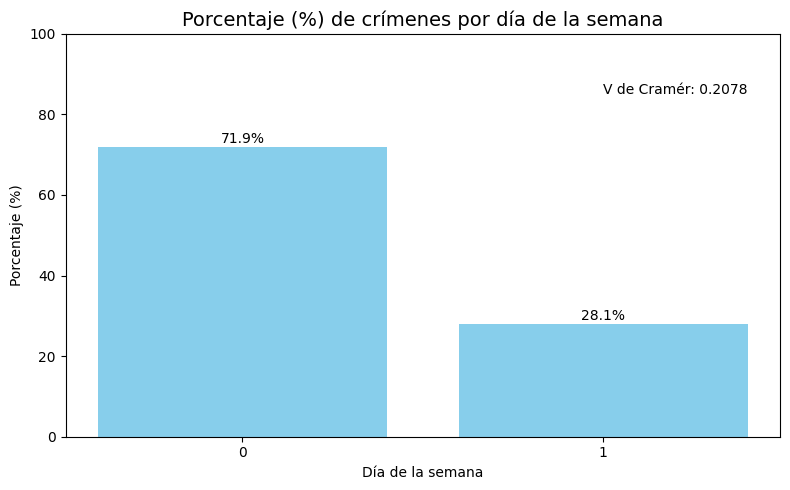

In [63]:
# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['sig'])

# Porcentajes
counts = train['sig'].value_counts(normalize=True) * 100

# Crear gráfico
plt.figure(figsize=(8,5))
bars = plt.bar(counts.index.astype(str), counts.values, color='skyblue')  # ← Convertir a string
plt.title('Porcentaje (%) de crímenes por día de la semana', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Día de la semana')
plt.ylim(0, 100)
# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10)
# Añadir texto V de Cramér
plt.text(len(counts)-1, 85, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10)
plt.tight_layout()
plt.show()

### Variable: Label 

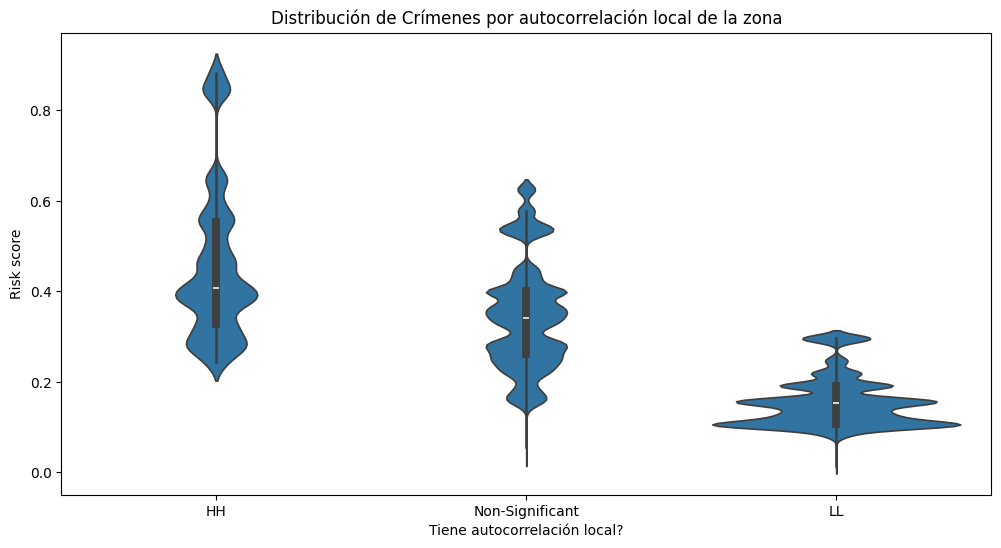

In [64]:
# Se compara con el risk score mediante un boxplot
plt.figure(figsize=(12, 6))
sns.violinplot(data=train, x='labels', y = 'risk_score')
plt.title('Distribución de Crímenes por autocorrelación local de la zona')
plt.xlabel('Tiene autocorrelación local?')
plt.ylabel('Risk score')
plt.show()

La variable label clasifica a las zonas en su respectiva autocorrelación espacial. Los HH son zonas de alto crimen rodeadas también de zonas de alto crimen por lo que hace total sentido que presenten indicadores de riesgos más altos.

Contrario sucede con las zonas LL, que son de bajo crimen y presentan niveles considerablemente más bajos que el resto. 

La categoría Non-Significant es porque no hubo una autocorrelación espacial significativa en esas zonas así que hace sentido que sea un punto medio entre ambas. 

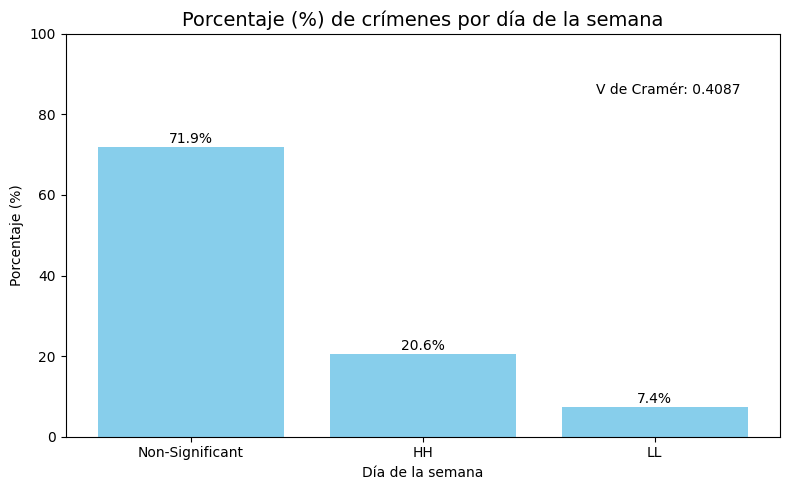

In [65]:
# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['labels'])

# Porcentajes
counts = train['labels'].value_counts(normalize=True) * 100

# Crear gráfico
plt.figure(figsize=(8,5))
bars = plt.bar(counts.index.astype(str), counts.values, color='skyblue')  # ← Convertir a string
plt.title('Porcentaje (%) de crímenes por día de la semana', fontsize=14)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Día de la semana')
plt.ylim(0, 100)
# Etiquetas en cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', fontsize=10)
# Añadir texto V de Cramér
plt.text(len(counts)-1.255, 85, f"V de Cramér: {round(cramerV['cramers_v'].iloc[0], 4):.4f}", fontsize=10)
plt.tight_layout()
plt.show()

La V de Cramer lo confirma, sí existe una asociación moderada-fuerte entre el label asignado a cada zona y su respectivo risk score. A modo de conclusión:

- Las zonas HH requieren mayor atención policial
- Las zonas LL pueden servir como modelos de seguridad
- Hay evidencia para decir que esta variable aportará poder predictivo al modelo.

### Variable: ZCTA

Graficar esta variable no es lo visualmente ideal dado a su alta cardinalidad, pero si nos fijamos en su V de Cramer parecer ser una variable que tiene una leve asociación con el risk level, sin embargo, esto puede deberse a que dentro de cada código la relación es local y no global, como en efecto ya comprobamos con el label.  

In [66]:
# V de Cramer
cramerV = chi2_cramersv(df = train, target='risk_level', cat_vars=['ZCTA'])
cramerV

,variable,p_value,cramers_v
0,ZCTA,0.0,0.760518


In [70]:
zcta_denom = train.groupby('ZCTA').agg(
    n_crimes=('ZCTA', 'count')
).reset_index()
zcta_denom

,ZCTA,n_crimes
0,19004,2
1,19012,2
2,19027,4
3,19038,4
4,19066,2
5,19095,2
6,19102,1925
7,19103,2794
8,19104,5753
9,19106,1525


In [71]:
train = train.merge(right=zcta_denom[['ZCTA', 'n_crimes']], how='left', on='ZCTA')

In [72]:
train['n_crimes_X_risk_score_lag'] = train['n_crimes'] * train['risk_score_lag']

In [73]:
correlation = train['risk_score'].corr(train['n_crimes_X_risk_score_lag'])
correlation

0.44040860532048115

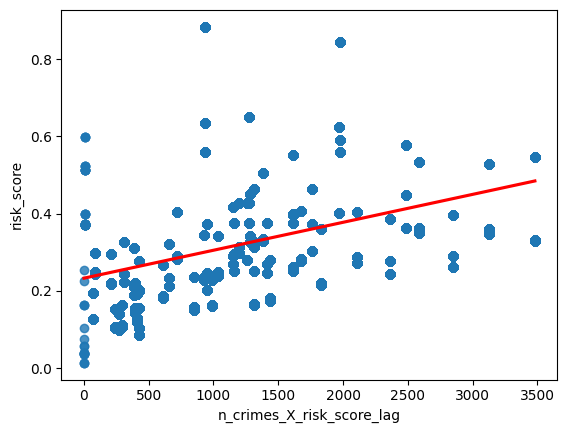

In [74]:
sns.regplot(
    x='n_crimes_X_risk_score_lag',
    y="risk_score",
    data=train,
    ci=None,
    line_kws={"color": "r"}
)
plt.show()

## Modelado

In [93]:
TARGET = 'risk_level'

final_features = [
    # 'white_race', 
    # 'others_races',
    'median_income',
    'household_25k_or_less', 
    'household_25k_to_50k', 
    'household_50k_to_150k', 
    'household_150k_or_more', 
    'GiniIndex', 
    'risk_score_lag', 
    # 'dc_dist_grouped',
    'time_of_day',
    # 'sig', 
    # 'labels',
    'risk_level'
]

train_model = train[final_features].dropna()
val_model = val[final_features].dropna()
test_model = test[final_features].dropna()

y_train = train_model[TARGET]
y_valid = val_model[TARGET]
y_test = test_model[TARGET]

X_train_model = train_model[final_features].drop('risk_level', axis=1)
X_val_model = val_model[final_features].drop('risk_level', axis=1)
X_test_model = test_model[final_features].drop('risk_level', axis=1)

# Se dividen las variables entre numericas o categoricas
num_features = [
    # 'white_race',
    # 'others_races',
    'median_income',
    'household_25k_or_less', 'household_25k_to_50k',
    'household_50k_to_150k', 'household_150k_or_more', 'GiniIndex',
    # 'risk_score_lag'
]

cat_features = [
    #'dc_dist_grouped', 
    'time_of_day', 
    #'sig', 
    #'labels'
]

# Asegurar que todas las columnas categóricas sean de tipo category
for col in cat_features:
    if col in X_train_model.columns:
        X_train_model[col] = X_train_model[col].astype(str)
        X_val_model[col] = X_val_model[col].astype(str)
        X_test_model[col] = X_test_model[col].astype(str)
        

In [94]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

preprocessor.fit(X_train_model)

X_train_processed = preprocessor.transform(X_train_model)
X_val_processed   = preprocessor.transform(X_val_model)
X_test_processed  = preprocessor.transform(X_test_model)

In [95]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

In [ ]:
# clf = Pipeline(steps=[('preprocess', preprocessor), ('model', rf)])
# pipe = Pipeline(steps=[('preprocess', preprocessor), ('model', rf)])

In [ ]:
# 4) Cross-validation setup
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Fold 1 accuracy:
0.9999126357785608
Fold 1 macro F1:
0.9998861611481238
Fold 2 accuracy:
1.0
Fold 2 macro F1:
1.0
Fold 3 accuracy:
0.9998835143714144
Fold 3 macro F1:
0.9998716034696219
Fold 4 accuracy:
0.9999708785928536
Fold 4 macro F1:
0.9999679024221999
Fold 5 accuracy:
1.0
Fold 5 macro F1:
1.0
Mean accuracy:
0.9999534057485657
Std accuracy:
4.731668601086736e-05
Mean macro F1:
0.9999451334079892
Std macro F1:
5.5540063226143464e-05


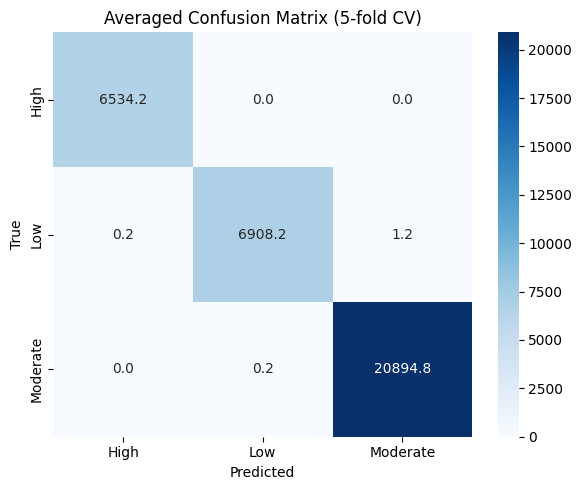

Displayed averaged confusion matrix plot


In [ ]:
# acc_scores = []
# macro_f1_scores = []
# conf_mats = []
# class_order = np.unique(y_train)

# fold_idx = 1
# for train_idx, test_idx in skf.split(X_train_model, y_train):
#     X_tr, X_te = X_train_model.iloc[train_idx], X_train_model.iloc[test_idx]
#     y_tr, y_te = y_train.iloc[train_idx], y_train.iloc[test_idx]

#     pipe.fit(X_tr, y_tr)
#     y_pred = pipe.predict(X_te)

#     acc = accuracy_score(y_te, y_pred)
#     f1m = f1_score(y_te, y_pred, average='macro')

#     acc_scores.append(acc)
#     macro_f1_scores.append(f1m)
#     cm = confusion_matrix(y_te, y_pred, labels=class_order)
#     conf_mats.append(cm)

#     print('Fold ' + str(fold_idx) + ' accuracy:')
#     print(acc)
#     print('Fold ' + str(fold_idx) + ' macro F1:')
#     print(f1m)
#     fold_idx += 1

# print('Mean accuracy:')
# print(float(np.mean(acc_scores)))
# print('Std accuracy:')
# print(float(np.std(acc_scores)))
# print('Mean macro F1:')
# print(float(np.mean(macro_f1_scores)))
# print('Std macro F1:')
# print(float(np.std(macro_f1_scores)))

# # 5) Plot averaged confusion matrix
# avg_cm = np.mean(conf_mats, axis=0)
# plt.figure(figsize=(6,5))
# sns.heatmap(avg_cm, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_order, yticklabels=class_order)
# plt.title('Averaged Confusion Matrix (5-fold CV)')
# plt.xlabel('Predicted')
# plt.ylabel('True')
# plt.tight_layout()
# plt.show()
# print('Displayed averaged confusion matrix plot')

Mean accuracy:
0.9999534057485657
Std accuracy:
4.731668601086736e-05
Mean macro F1:
0.9999451334079892
Std macro F1:
5.5540063226143464e-05


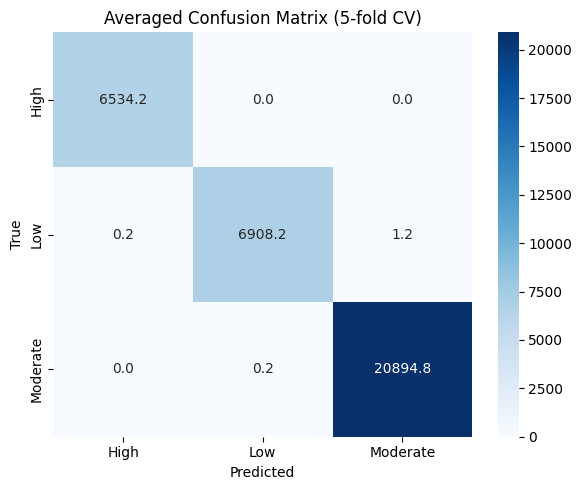

Displayed averaged confusion matrix plot


In [81]:
print('Mean accuracy:')
print(float(np.mean(acc_scores)))
print('Std accuracy:')
print(float(np.std(acc_scores)))
print('Mean macro F1:')
print(float(np.mean(macro_f1_scores)))
print('Std macro F1:')
print(float(np.std(macro_f1_scores)))

# 5) Plot averaged confusion matrix
avg_cm = np.mean(conf_mats, axis=0)
plt.figure(figsize=(6,5))
sns.heatmap(avg_cm, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_order, yticklabels=class_order)
plt.title('Averaged Confusion Matrix (5-fold CV)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()
print('Displayed averaged confusion matrix plot')

In [96]:
# 6) Train
rf.fit(X_train_processed, y_train)
print('Model trained')

Model trained


In [98]:
y_val_pred = rf.predict(X_val_processed)
print('Validation classification report:')
print(classification_report(y_valid, y_val_pred, zero_division=0))

Validation classification report:
              precision    recall  f1-score   support

        High       0.04      1.00      0.07       244
         Low       1.00      0.22      0.36     30692
    Moderate       0.01      0.08      0.02      2587

    accuracy                           0.22     33523
   macro avg       0.35      0.43      0.15     33523
weighted avg       0.92      0.22      0.33     33523



In [100]:
# 8) Test
y_test_pred = rf.predict(X_test_processed)
print('Test classification report:')
print(classification_report(y_test, y_test_pred, zero_division=0))

Test classification report:
              precision    recall  f1-score   support

        High       0.04      1.00      0.08       284
         Low       1.00      0.22      0.36     34464
    Moderate       0.02      0.20      0.04      2771

    accuracy                           0.23     37519
   macro avg       0.36      0.47      0.16     37519
weighted avg       0.92      0.23      0.34     37519



In [105]:
cm_val = confusion_matrix(y_valid, y_val_pred, labels=['Low', 'Moderate', 'High'])
cm_val_df = pd.DataFrame(cm_val, index=['True Low','True Moderate','True High'], columns=['Pred Low','Pred Moderate','Pred High'])
print('Validation confusion matrix (rows true, cols pred):')
print(cm_val_df)

Validation confusion matrix (rows true, cols pred):
               Pred Low  Pred Moderate  Pred High
True Low           6775          20133       3784
True Moderate         0            208       2379
True High             0              0        244


In [106]:
cm_test = confusion_matrix(y_test, y_test_pred, labels=['Low', 'Moderate', 'High'])
cm_test_df = pd.DataFrame(cm_test, index=['True Low','True Moderate','True High'], columns=['Pred Low','Pred Moderate','Pred High'])
print('Test confusion matrix (rows true, cols pred):')
print(cm_test_df)

Test confusion matrix (rows true, cols pred):
               Pred Low  Pred Moderate  Pred High
True Low           7656          22357       4451
True Moderate         0            560       2211
True High             0              0        284


In [102]:
# 9) Feature importance mapping to original features (after one-hot)
# Extract trained components
rf_model = clf.named_steps['model']
ohe = clf.named_steps['preprocess'].named_transformers_['cat']

# Build feature names after preprocessing
num_feature_names = num_features
cat_feature_names = list(ohe.get_feature_names_out(cat_features))
all_feature_names = num_feature_names + cat_feature_names

importances = rf_model.feature_importances_
fi_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances}).sort_values('importance', ascending=False)

print('Top 15 feature importances:')
print(fi_df.head(15))

AttributeError: 'ColumnTransformer' object has no attribute 'transformers_'

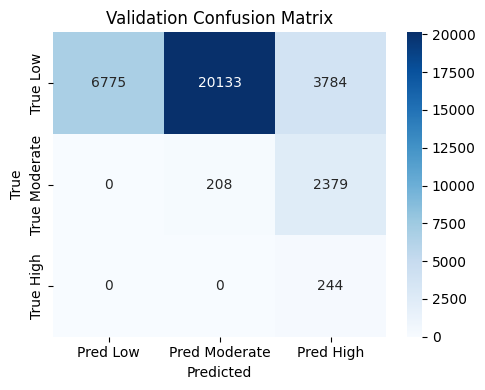

In [103]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_val_df, annot=True, fmt='d', cmap='Blues')
plt.title('Validation Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

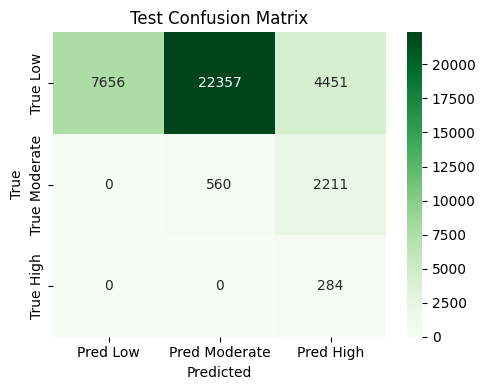

In [107]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_test_df, annot=True, fmt='d', cmap='Greens')
plt.title('Test Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

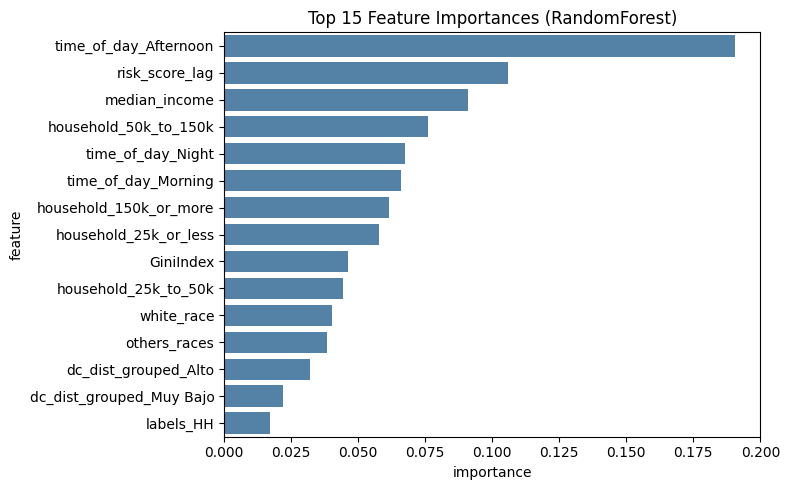

In [55]:
plt.figure(figsize=(8,5))
sns.barplot(x='importance', y='feature', data=fi_df.head(15), color='steelblue')
plt.title('Top 15 Feature Importances (RandomForest)')
plt.tight_layout()
plt.show()


## XGBoost

In [130]:
# ----------------------------
# Model
# ----------------------------
""" xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    objective='multi:softprob',     # clasificación múltiple
    num_class=3,
    eval_metric='mlogloss'
) """

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    reg_alpha= 1,       # Añadir regularización
    reg_lambda= 1,
    # subsample=0.8,
    # colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror',   # <<--- regresión
    eval_metric='rmse'              # <<--- métrica típica de regresión
)

In [131]:
# Se ajustan los datos al modelo ya creado
xgb.fit(
    X_train_processed, 
    y_train, 
    eval_set=[(X_valid_processed, y_valid)], verbose=True
)

[0]	validation_0-rmse:0.19487
[1]	validation_0-rmse:0.19299
[2]	validation_0-rmse:0.19187
[3]	validation_0-rmse:0.19122
[4]	validation_0-rmse:0.19102
[5]	validation_0-rmse:0.19110
[6]	validation_0-rmse:0.19144
[7]	validation_0-rmse:0.19174
[8]	validation_0-rmse:0.19223
[9]	validation_0-rmse:0.19276
[10]	validation_0-rmse:0.19344
[11]	validation_0-rmse:0.19339
[12]	validation_0-rmse:0.19410
[13]	validation_0-rmse:0.19484
[14]	validation_0-rmse:0.19498
[15]	validation_0-rmse:0.19564
[16]	validation_0-rmse:0.19576
[17]	validation_0-rmse:0.19628
[18]	validation_0-rmse:0.19694
[19]	validation_0-rmse:0.19699
[20]	validation_0-rmse:0.19734
[21]	validation_0-rmse:0.19777
[22]	validation_0-rmse:0.19801
[23]	validation_0-rmse:0.19844
[24]	validation_0-rmse:0.19855
[25]	validation_0-rmse:0.19885
[26]	validation_0-rmse:0.19927
[27]	validation_0-rmse:0.19947
[28]	validation_0-rmse:0.19981
[29]	validation_0-rmse:0.19992
[30]	validation_0-rmse:0.20022
[31]	validation_0-rmse:0.20042
[32]	validation_0-

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

## Métricas para Regresión

In [132]:
y_pred = np.clip(xgb.predict(X_valid_processed), 0.0, 1.0)

# Example evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print("RMSE:", mean_squared_error(y_valid, y_pred, squared=False))
print("MAE:", mean_absolute_error(y_valid, y_pred))
print("R2:", r2_score(y_valid, y_pred))

RMSE: 0.20174843327938566
MAE: 0.18273093027755344
R2: -8.572900354735507


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [134]:
print("Correlación target con features:")
correlations = X_train_processed.corrwith(y_train).sort_values(ascending=False)
print(correlations.head())

Correlación target con features:


AttributeError: 'numpy.ndarray' object has no attribute 'corrwith'

<Axes: >

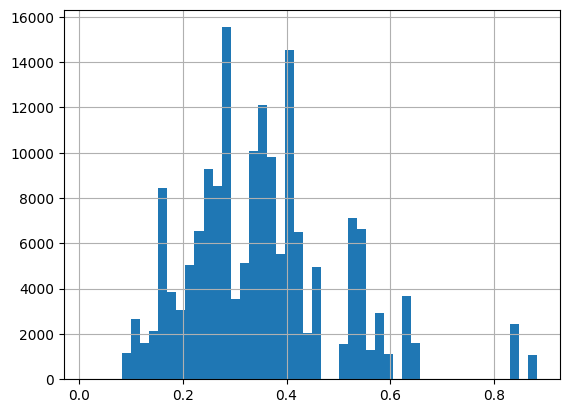

In [118]:
y_train.hist(bins=50)